# Diamond Price Prediction

---


---

### **Feature Overview**

| Feature | Description | Impact on Valuation |
| :--- | :--- | :--- |
| **Carat** | The physical weight (1 carat = 200mg). | **Primary Driver:** Larger diamonds are exponentially rarer and more costly. |
| **Cut** | Quality of the facets (Ideal to Fair). | **Brilliance:** Higher quality cuts reflect light better, increasing sparkle and price. |
| **Color** | Grade from D (Colorless) to J (Visible tint). | **Rarity:** D is the most expensive; J is more common and affordable. |
| **Clarity** | Purity level (Inclusions/Blemishes). | **Purity:** Fewer internal imperfections result in a higher market premium. |
| **x, y, z** | Length, width, and depth in mm. | **Geometry:** Physical dimensions that correlate with weight and shape. |
| **Depth** | Total depth percentage. | **Light Travel:** Crucial for determining how light travels through the stone. |
| **Table** | Width of the top facet. | **Brilliance:** Affects the diamond's overall reflection and "fire." |
| **Price** | **Target Variable** | The final value in USD, aim to predict. |

---

> **Insight:** While carat weight provides the baseline value, the interplay between Cut, Color, and Clarity allows the model to refine predictions for high-end or specialty stones.

In [14]:
# import all nesecarry libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("\nLibraries used:")
print("- pandas: for data manipulation")
print("- sklearn: for ML models and metrics")
print("- matplotlib/seaborn: for visualization")
print("- xgboost: for XGBoost algorithm")

Libraries imported successfully!

Libraries used:
- pandas: for data manipulation
- sklearn: for ML models and metrics
- matplotlib/seaborn: for visualization
- xgboost: for XGBoost algorithm


In [15]:
#Create a requirements.txt file with all the libraries and the versions used in the project
!pip freeze > ../images/requirements.txt

In [16]:
#UNBOXING OF THE DATASET
df = pd.read_csv('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/Data/Diamond_Price_ Kaggle.csv', index_col=0)
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [17]:
print("\nDataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
df.describe()


Dataset shape: (53940, 10)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB
None


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [18]:
#Checking for missing values
print("\nMissing values in each column:")
print(df.isnull().sum()) #No missing values found in the dataset (we conclude)

# Check for weird values (x, y, z should not be 0)
print("\nChecking for zero values in dimensions:")
print(f"Zero dimensions: x={sum(df.x==0)}, y={sum(df.y==0)}, z={sum(df.z==0)}") 
# So now we have some zero values in x, y, z columns which is not possible for a diamond.
# now we have 2 option either to drop this data or to impute it with mean or median. Since the number of zero values is very less we can drop this data. 

# Dropping rows with zero dimensions
df = df[(df.x != 0) & (df.y != 0) & (df.z != 0)]
print("\nShape after dropping zero dimension rows:", df.shape)

#verify are there any zeros in x y and z 
print(f"Zero dimensions: x={sum(df.x==0)}, y={sum(df.y==0)}, z={sum(df.z==0)}")  #Perfect we are not left with any zero values in x, y, z columns.


Missing values in each column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Checking for zero values in dimensions:
Zero dimensions: x=8, y=7, z=20

Shape after dropping zero dimension rows: (53920, 10)
Zero dimensions: x=0, y=0, z=0


In [19]:
#Apply Feature Engineering to create a new feature called by converting 
# color, clarity and cut into numerical values using Label Encoding.
df_featured = df.copy()  # Create a copy of the original dataframe for feature engineering

#Mapping the categorical values to numerical values based on their quality order lowest to highest
cut_mapping = {"Fair": 1, "Good": 2, "Very Good": 3, "Premium": 4, "Ideal": 5} #ideal is 5
color_mapping = {"J": 1, "I": 2, "H": 3, "G": 4, "F": 5, "E": 6, "D": 7}
clarity_map = {"I1": 1, "SI2": 2, "SI1": 3, "VS2": 4, "VS1": 5, "VVS2": 6, "VVS1": 7, "IF": 8}

# Now we will map the categorical values to numerical values in the dataframe
df_featured['cut'] = df_featured['cut'].map(cut_mapping)
df_featured['color'] = df_featured['color'].map(color_mapping)
df_featured['clarity'] = df_featured['clarity'].map(clarity_map)

df_featured.head()  # Display the first few rows of the featured dataframe to verify the changes

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,5,6,2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,4,6,3,59.8,61.0,326,3.89,3.84,2.31
3,0.23,2,6,5,56.9,65.0,327,4.05,4.07,2.31
4,0.29,4,2,4,62.4,58.0,334,4.20,4.23,2.63
5,0.31,2,1,2,63.3,58.0,335,4.34,4.35,2.75


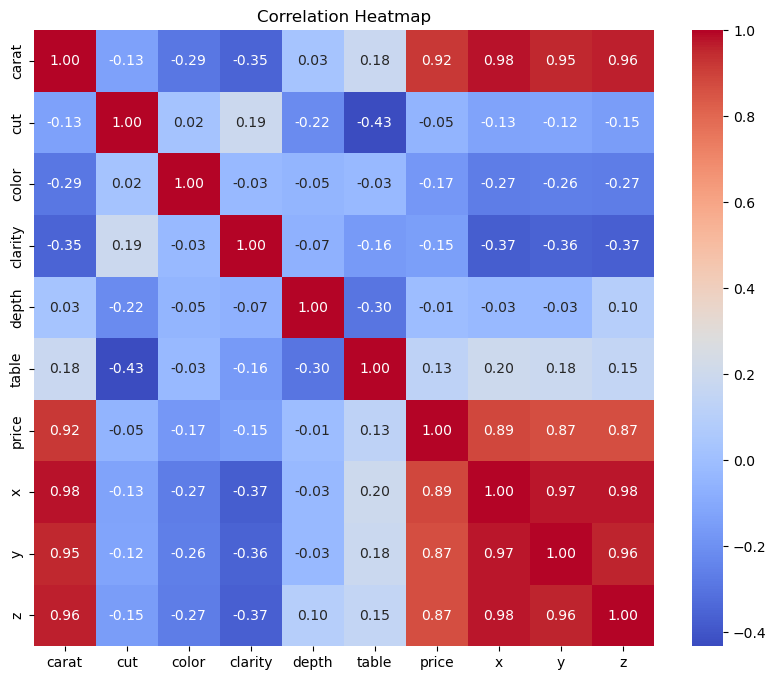

In [20]:
# Now we will create a Heat Map to visualize the correlation between the features
plt.figure(figsize=(10, 8))
sns.heatmap(df_featured.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')       
plt.show()

## Key Insights from the Correlation Heatmap

heatmap illustrates the relationships within the **Diamonds dataset**. The values range from **-1.0** (perfect inverse relationship) to **1.0** (perfect positive relationship).

### 1. The Price Drivers (Strongest Positive Correlations)
The most critical takeaway is the near-perfect relationship between a diamond's physical mass and its market value.

* **Carat & Price (0.92):** This is the dominant relationship. Weight is the primary predictor of cost.
* **Dimensions (x, y, z) & Price (0.87 - 0.89):** As length, width, and depth increase, the price climbs significantly.
* **Dimensions & Carat (0.95 - 0.98):** These variables are almost perfectly correlated because weight is a function of volume.

### 2. The Multicollinearity Cluster
the red block in the bottom-right corner is a major "red flag" for linear modeling:

* **x, y, and z** are so highly correlated with each other (up to **0.98**) that including all of them in a regression model alongside **carat** would likely cause **multicollinearity**. 


### 3. Counter-Intuitive Weak Correlations
Surprisingly, the "Quality" metrics show very low linear correlation with price:

* **Cut (-0.05), Color (-0.17), and Clarity (-0.15):** These show weak negative correlations. 
* **The Reason:** This doesn't mean they don't affect price. Instead, it suggests a "trade-off" in the market—larger diamonds (high carat) often have lower clarity or color grades to keep them at a sellable price point. These features likely have a **non-linear** impact.

### 4. Physical Proportions
* **Table vs. Cut (-0.43):** This is the strongest negative correlation. It suggests that as the "table" (the top flat facet) gets wider, the overall cut grade tends to drop.
* **Depth & Table:** These show very little relationship with price (**-0.01** and **0.13** respectively), indicating they are secondary to the "4 Cs."

---

### Summary Table for Modeling

| Feature Type  | Variables             | Impact on Price      |
|--------------|----------------------|----------------------|
| **Primary**  | Carat, x, y, z       | Extremely High       |
| **Secondary**| Cut, Color, Clarity  | Low (Linear)         |
| **Proportional** | Depth, Table     | Negligible           |


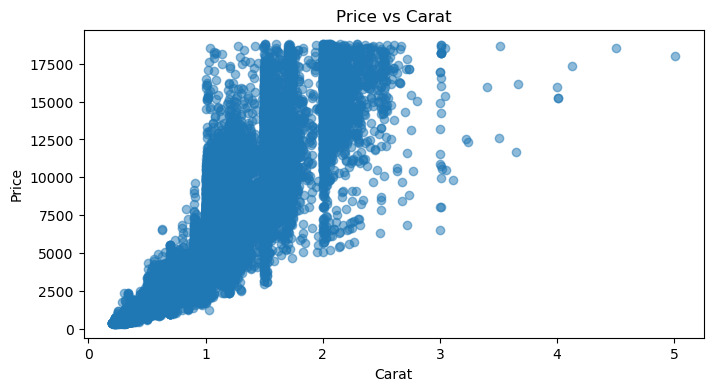

In [21]:
# Price vs Carat (THE most important relationship)
plt.figure(figsize=(8, 4))
plt.scatter(df_featured['carat'], df_featured['price'], alpha=0.5)
plt.title('Price vs Carat')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()


# Analysis of Price vs. Carat

---

### **The Fundamental Relationship**
The relationship between **Carat** and **Price** is the most significant correlation in the dataset. As the carat weight increases, the price of the diamond rises following an upward trend. This visual analysis confirms that size is the primary driver of market valuation.

### **Data Distribution and Density**
By examining the scatter distribution, we can identify key characteristics of the dataset:
* **Correlation:** A clear positive trend where higher carat values consistently command higher prices.
* **Data Concentration:** The majority of the observations are concentrated between **0.0 and 3.0 carats**.
* **Sparsity:** Data points become increasingly sparse for diamonds exceeding 3.0 carats, reflecting the natural rarity of larger stones.

---

> **Technical Note:** While the relationship is positive, it is often non-linear. Smaller increases in carat weight typically lead to disproportionately larger jumps in price, especially as the diamond crosses key thresholds (e.g., 1.0ct, 2.0ct).

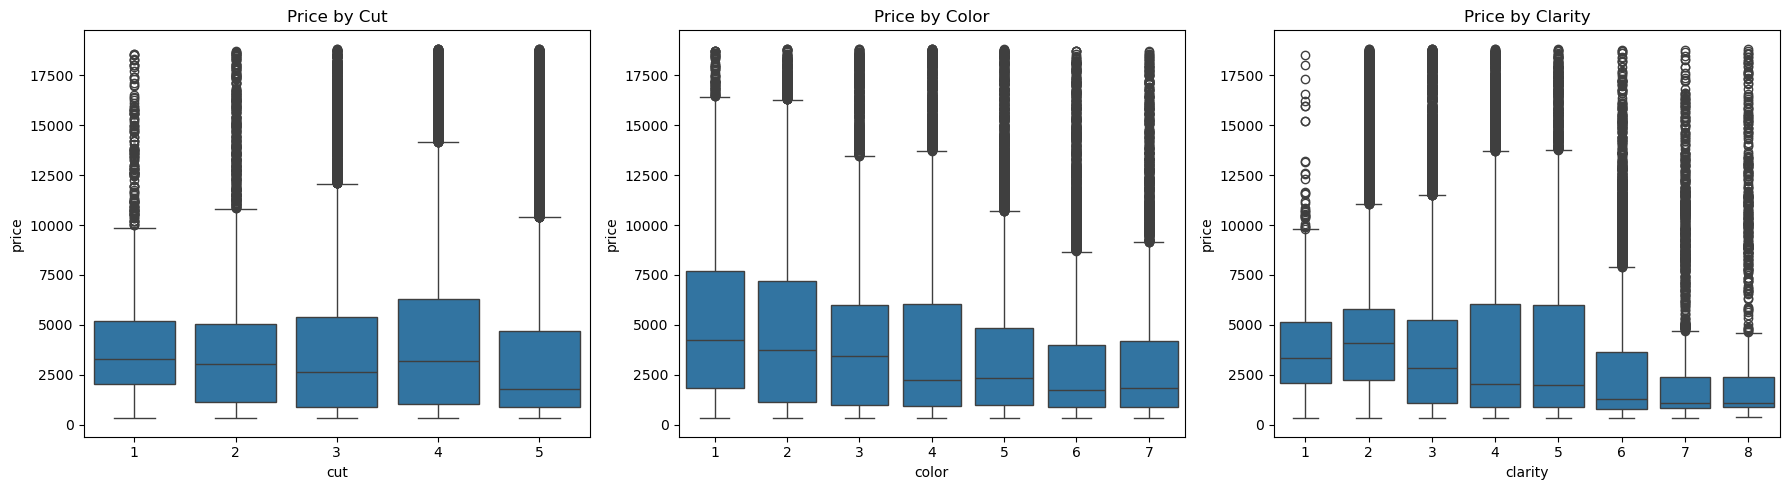

In [22]:
# Price by categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_featured, x='cut', y='price', ax=axes[0])
axes[0].set_title('Price by Cut')

sns.boxplot(data=df_featured, x='color', y='price', ax=axes[1])
axes[1].set_title('Price by Color')

sns.boxplot(data=df_featured, x='clarity', y='price', ax=axes[2])
axes[2].set_title('Price by Clarity')

plt.tight_layout()
plt.show()


# Categorical Feature Analysis

---

### **Key Observations from Visualizations**

The box plots illustrate the relationship between categorical features (Cut, Color, Clarity) and diamond prices. Below are the primary insights:

#### **1. Price by Cut**
* **Distribution Overlap:** There is a significant overlap in price distributions across all cut qualities (Ideal to Fair).
* **Premium Premium:** Surprisingly, **Premium** and **Fair** cuts show slightly higher median prices compared to **Ideal** cuts. This suggests that "Ideal" cut diamonds in this dataset might be smaller in carat weight, while larger diamonds with lower cut grades are driving higher prices.
* **Outliers:** All categories contain a high density of outliers reaching the $17,500+ range.

#### **2. Price by Color**
* **Inverted Price Trend:** Lower-grade colors (specifically **I** and **J**) show higher median prices and larger interquartile ranges (IQR) than high-grade colors like **D** or **E**.
* **Rationale:** This often indicates that in this specific dataset, the diamonds with poorer color grades (J, I) are likely much larger in size (Carat), which overrides the color premium in the final price.

#### **3. Price by Clarity**
* **Clarity Paradox:** Lower clarity grades such as **SI2** and **I1** exhibit higher median prices than premium grades like **IF** (Internally Flawless) or **VWS1**.
* **Impact of Size:** Similar to the color analysis, high-clarity diamonds are often smaller. The larger "SI2" or "SI1" diamonds command higher prices due to their weight, despite having more visible inclusions.

---

### **Summary Conclusion**
The visualizations reveal a **counter-intuitive relationship**: high-quality categorical grades (Ideal Cut, D Color, IF Clarity) do not automatically result in the highest prices in this dataset. This strongly suggests that **Carat weight** acts as a confounding variable that significantly outweighs the influence of individual categorical quality metrics.

### SPLITTING THE DATA INTO TRAIN AND TEST SETS

In [23]:
#prepare the feature matrix X and target vector y for modeling
X = df_featured.drop('price', axis=1)  # Features (all columns except 'price')
y = df_featured['price']  # Target variable Price is the target variable we want to predict.

# Now split the data into training and testing sets using an 80-20 split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets successfully!")
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}") # we have 43136 samples in the training set and 10784 samples in the testing set


Data split into training and testing sets successfully!
Training set shape: X_train=(43136, 9), y_train=(43136,)
Testing set shape: X_test=(10784, 9), y_test=(10784,)


### Training Linear Regression model..


In [24]:
print("\n" + "="*50)
print("Training Linear Regression model...")
print("="*50)

lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
lr_train_pred = lr.predict(X_train)
lr_test_pred = lr.predict(X_test)

#Metrics
lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_test_pred_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))
lr_train_mae = mean_absolute_error(y_train, lr_train_pred)
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)

# Print results
print(f"Linear Regression - Training RMSE: {lr_train_rmse:.2f}, Testing RMSE: {lr_test_pred_rmse:.2f}")
print(f"Linear Regression - Training MAE: {lr_train_mae:.2f}, Testing MAE: {lr_test_mae:.2f}")
print(f"Linear Regression - Training R²: {lr_train_r2:.4f}, Testing R²: {lr_test_r2:.4f}")




Training Linear Regression model...
Linear Regression - Training RMSE: 1226.53, Testing RMSE: 1201.39
Linear Regression - Training MAE: 805.26, Testing MAE: 790.37
Linear Regression - Training R²: 0.9052, Testing R²: 0.9100


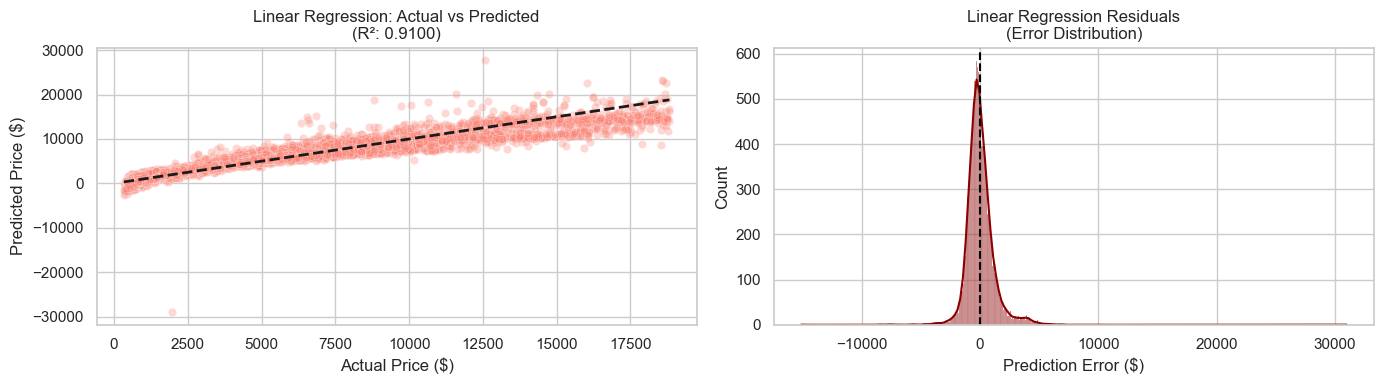

In [25]:
# Set professional theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 4))

# 1. Actual vs Predicted: The "Line of Best Fit"
plt.subplot(1, 2, 1)
# Use 'lr_test_pred' from your model results
sns.scatterplot(x=y_test, y=lr_test_pred, alpha=0.3, color='salmon')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f'Linear Regression: Actual vs Predicted\n(R²: {lr_test_r2:.4f})')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

# 2. Residual Plot: Checking for Heteroscedasticity
plt.subplot(1, 2, 2)
lr_residuals = y_test - lr_test_pred
sns.histplot(lr_residuals, kde=True, color='darkred')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Linear Regression Residuals\n(Error Distribution)')
plt.xlabel('Prediction Error ($)')

plt.tight_layout()
plt.show()

### Training AdaBoost Regressor model...

In [26]:
print("\n" + "="*50)
print("Training AdaBoost Regressor model...")
print("="*50)

ada = AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

# Predictions
ada_train_pred = ada.predict(X_train)
ada_test_pred = ada.predict(X_test)

# Metrics
ada_train_rmse = np.sqrt(mean_squared_error(y_train, ada_train_pred))
ada_test_rmse = np.sqrt(mean_squared_error(y_test, ada_test_pred))
ada_train_mae = mean_absolute_error(y_train, ada_train_pred)
ada_test_mae = mean_absolute_error(y_test, ada_test_pred)
ada_train_r2 = r2_score(y_train, ada_train_pred)
ada_test_r2 = r2_score(y_test, ada_test_pred)

# Print results
print(f"AdaBoost - Training RMSE: {ada_train_rmse:.2f}, Testing RMSE: {ada_test_rmse:.2f}")
print(f"AdaBoost - Training MAE: {ada_train_mae:.2f}, Testing MAE: {ada_test_mae:.2f}")
print(f"AdaBoost - Training R²: {ada_train_r2:.4f}, Testing R²: {ada_test_r2:.4f}")



Training AdaBoost Regressor model...
AdaBoost - Training RMSE: 1350.27, Testing RMSE: 1364.33
AdaBoost - Training MAE: 1114.34, Testing MAE: 1122.37
AdaBoost - Training R²: 0.8851, Testing R²: 0.8839


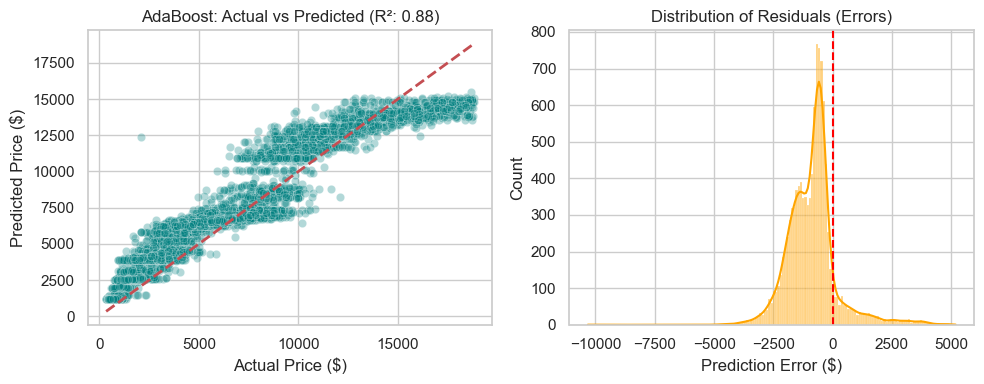

In [27]:

# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 4))

# Plot 1: Actual vs Predicted Prices
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=ada_test_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'AdaBoost: Actual vs Predicted (R²: {ada_test_r2:.2f})')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

# Plot 2: Residual Plot (Error Distribution)
plt.subplot(1, 2, 2)
residuals = y_test - ada_test_pred
sns.histplot(residuals, kde=True, color='orange')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Training Gradient Boosting Model

In [28]:
print("\n" + "="*50)
print("Training Gradient Boosting Model...")
print("="*50)

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

# Predictions
gb_train_pred = gb.predict(X_train)
gb_test_pred = gb.predict(X_test)

# Metrics
gb_train_rmse = np.sqrt(mean_squared_error(y_train, gb_train_pred))
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_test_pred))
gb_train_mae = mean_absolute_error(y_train, gb_train_pred)
gb_test_mae = mean_absolute_error(y_test, gb_test_pred)
gb_train_r2 = r2_score(y_train, gb_train_pred)
gb_test_r2 = r2_score(y_test, gb_test_pred)

# Print result 
print(f"Gradient Boosting - Training RMSE: {gb_train_rmse:.2f}, Testing RMSE: {gb_test_rmse:.2f}")
print(f"Gradient Boosting - Training MAE: {gb_train_mae:.2f}, Testing MAE: {gb_test_mae:.2f}")
print(f"Gradient Boosting - Training R²: {gb_train_r2:.4f}, Testing R²: {gb_test_r2:.4f}")
print("\n" + "="*50)





Training Gradient Boosting Model...


Gradient Boosting - Training RMSE: 594.94, Testing RMSE: 615.19
Gradient Boosting - Training MAE: 334.65, Testing MAE: 340.23
Gradient Boosting - Training R²: 0.9777, Testing R²: 0.9764



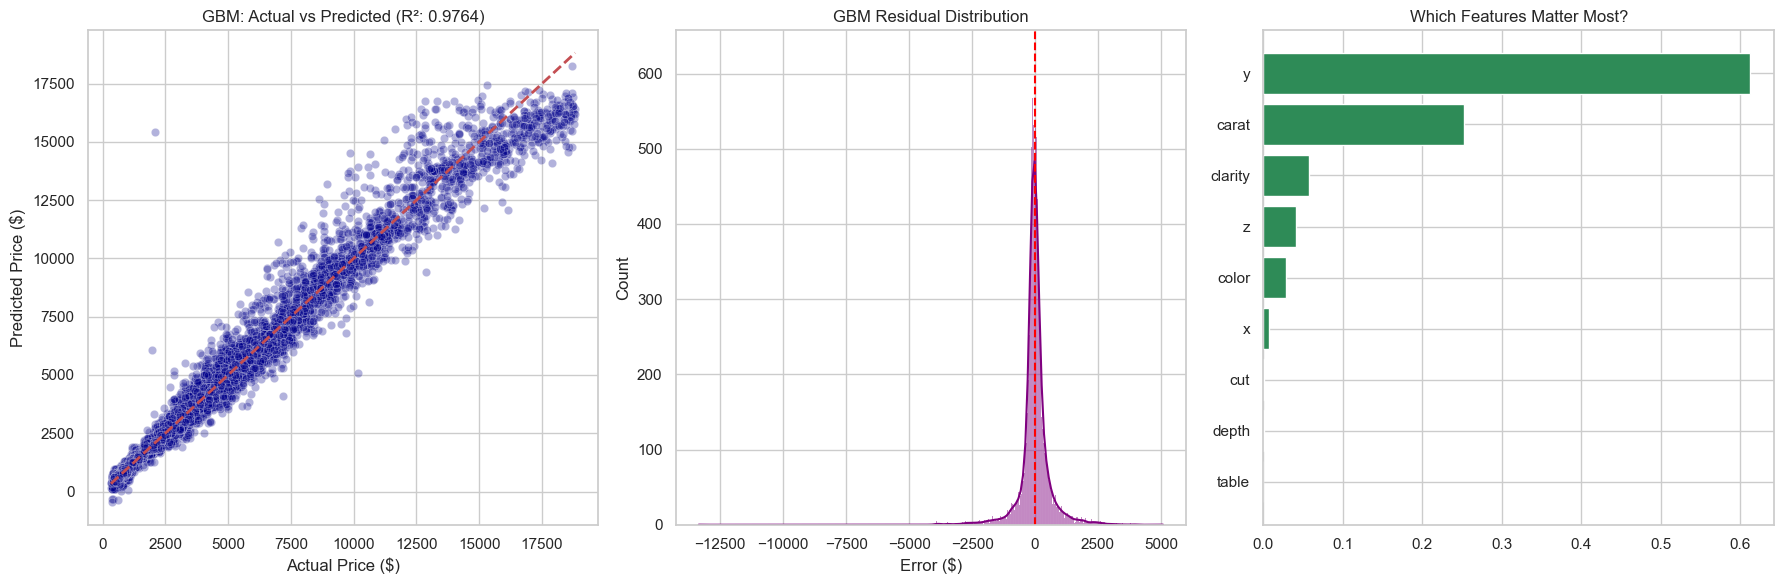

In [29]:
# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# 1. Actual vs Predicted (The "Success" Plot)
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=gb_test_pred, alpha=0.3, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'GBM: Actual vs Predicted (R²: {gb_test_r2:.4f})')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

# 2. Residual Distribution (The "Bias Check")
plt.subplot(1, 3, 2)
gb_residuals = y_test - gb_test_pred
sns.histplot(gb_residuals, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('GBM Residual Distribution')
plt.xlabel('Error ($)')

# 3. Feature Importance (The "Logic" Check)
plt.subplot(1, 3, 3)
importances = gb.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='seagreen')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Which Features Matter Most?')

plt.tight_layout()
plt.show()

### Traning XGBoost Model... 

In [30]:
print("\n" + "="*50)
print("Training XGBOOST Model...")
print("="*50)

xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb.fit(X_train, y_train)

# Predictions
xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

# Metrics
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
xgb_train_mae = mean_absolute_error(y_train, xgb_train_pred)
xgb_test_mae = mean_absolute_error(y_test, xgb_test_pred)
xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

# Print results
print(f"XGBoost - Training RMSE: {xgb_train_rmse:.2f}, Testing RMSE: {xgb_test_rmse:.2f}")
print(f"XGBoost - Training MAE: {xgb_train_mae:.2f}, Testing MAEL: {xgb_test_mae:.2f}")
print(f"XGBoost - Training R²: {xgb_train_r2:.4f}, Testing R²: {xgb_test_r2:.4f}")
print("\n" + "="*50)


Training XGBOOST Model...


XGBoost - Training RMSE: 604.12, Testing RMSE: 618.81
XGBoost - Training MAE: 336.98, Testing MAEL: 340.12
XGBoost - Training R²: 0.9770, Testing R²: 0.9761



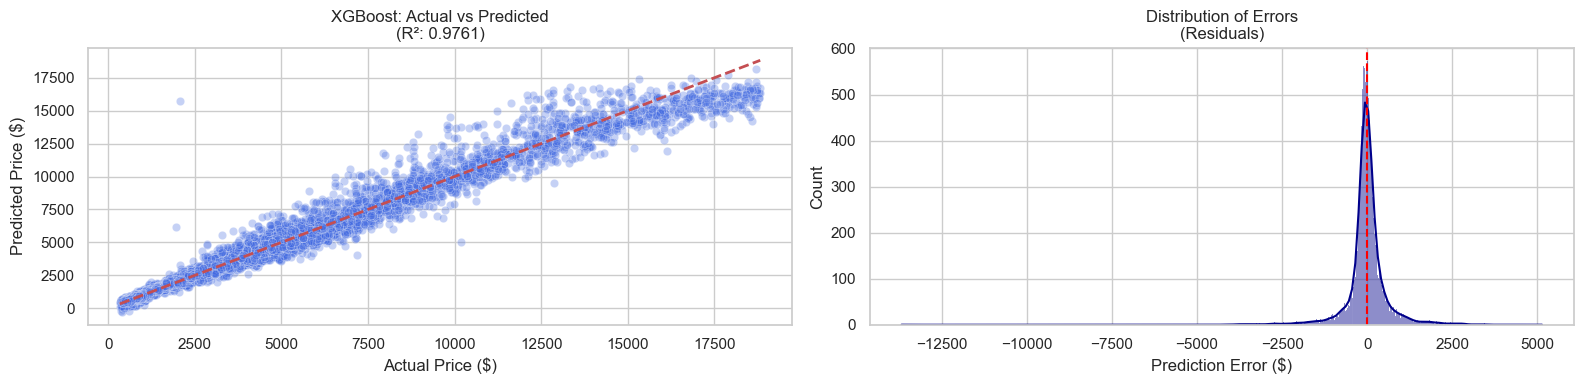

In [31]:
# Set the theme for a clean, academic look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 4))

# 1. Actual vs Predicted: Checking how well the model "fits" the reality
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=xgb_test_pred, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'XGBoost: Actual vs Predicted\n(R²: {xgb_test_r2:.4f})')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

# 2. Residuals: Checking if the errors are random or biased
plt.subplot(1, 2, 2)
xgb_residuals = y_test - xgb_test_pred
sns.histplot(xgb_residuals, kde=True, color='darkblue')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Errors\n(Residuals)')
plt.xlabel('Prediction Error ($)')

plt.tight_layout()
plt.show()

### Comparing all Models


FINAL MODEL COMPARISON
            Model  Train_RMSE  Test_RMSE  Test_MAE  R2_Score  Overfit_Gap
Linear Regression     1226.53    1201.39    790.37      0.91        25.14
         AdaBoost     1350.27    1364.33   1122.37      0.88       -14.06
Gradient Boosting      594.94     615.19    340.23      0.98       -20.25
          XGBoost      604.12     618.81    340.12      0.98       -14.69


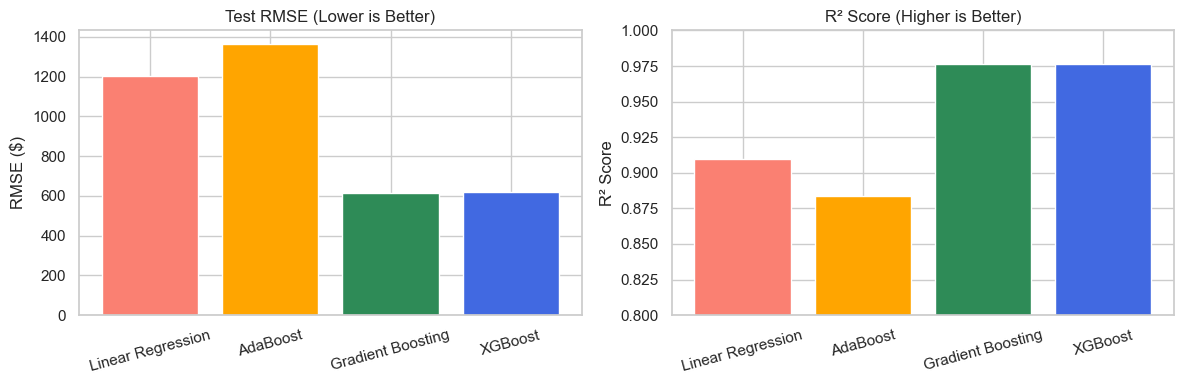

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the comparison table
# Note: I've updated the variable names to match what we calculated in previous steps
results = pd.DataFrame({
    'Model': ['Linear Regression', 'AdaBoost', 'Gradient Boosting', 'XGBoost'],
    'Train_RMSE': [lr_train_rmse, ada_train_rmse, gb_train_rmse, xgb_train_rmse],
    'Test_RMSE': [lr_test_pred_rmse, ada_test_rmse, gb_test_rmse, xgb_test_rmse],
    'Test_MAE': [lr_test_mae, ada_test_mae, gb_test_mae, xgb_test_mae],
    'R2_Score': [lr_test_r2, ada_test_r2, gb_test_r2, xgb_test_r2],
    'Overfit_Gap': [
        lr_train_rmse - lr_test_pred_rmse, 
        ada_train_rmse - ada_test_rmse, 
        gb_train_rmse - gb_test_rmse, 
        xgb_train_rmse - xgb_test_rmse
    ]
})

print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)
print(results.round(2).to_string(index=False))

# Visualize comparison
plt.figure(figsize=(12, 4))

# Subplot 1: RMSE Comparison
plt.subplot(1, 2, 1)
bars1 = plt.bar(results['Model'], results['Test_RMSE'], color=['salmon', 'orange', 'seagreen', 'royalblue'])
plt.title('Test RMSE (Lower is Better)')
plt.xticks(rotation=15)
plt.ylabel('RMSE ($)')

# Subplot 2: R² Score Comparison
plt.subplot(1, 2, 2)
bars2 = plt.bar(results['Model'], results['R2_Score'], color=['salmon', 'orange', 'seagreen', 'royalblue'])
plt.title('R² Score (Higher is Better)')
plt.xticks(rotation=15)
plt.ylabel('R² Score')
plt.ylim(0.8, 1.0) # Zooming in to see the performance gap clearly

plt.tight_layout()
plt.show()

## Advance Regression Analysis 

STEP 5: BIAS-VARIANCE DEMONSTRATION
Training samples: 43136
Test samples: 10784

MODEL 1: SIMPLE MODEL (Only 'carat' feature)
Train R²:  0.8476
Test R²:   0.8562
Train RMSE: $1554.98
Test RMSE:  $1518.37
Gap:        -0.0086

MODEL 2: MEDIUM MODEL (All features, no polynomials)
Train R²:  0.9052
Test R²:   0.9100
Train RMSE: $1226.53
Test RMSE:  $1201.39
Gap:        -0.0048

MODEL 3: COMPLEX MODEL (Polynomial Features degree=3)
Train R²:  0.9775
Test R²:   -10415.1675
Train RMSE: $597.48
Test RMSE:  $408645.92
Gap:        10416.1450

COMPARISON TABLE
                   Model  Train R²     Test R²  Train RMSE    Test RMSE  \
0    Simple (carat only)    0.8476      0.8562   1554.9753    1518.3737   
1  Medium (all features)    0.9052      0.9100   1226.5291    1201.3904   
2   Complex (poly deg 3)    0.9775 -10415.1675    597.4815  408645.9176   

   Gap (Train-Test)  
0           -0.0086  
1           -0.0048  
2        10416.1450  


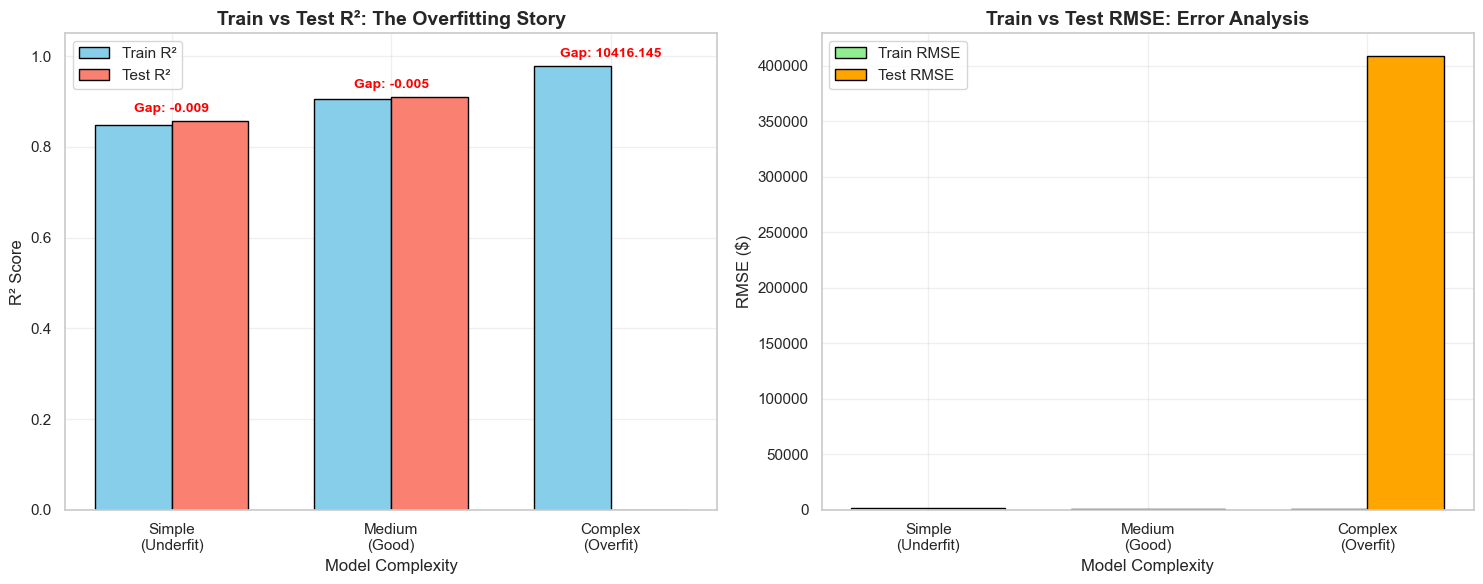

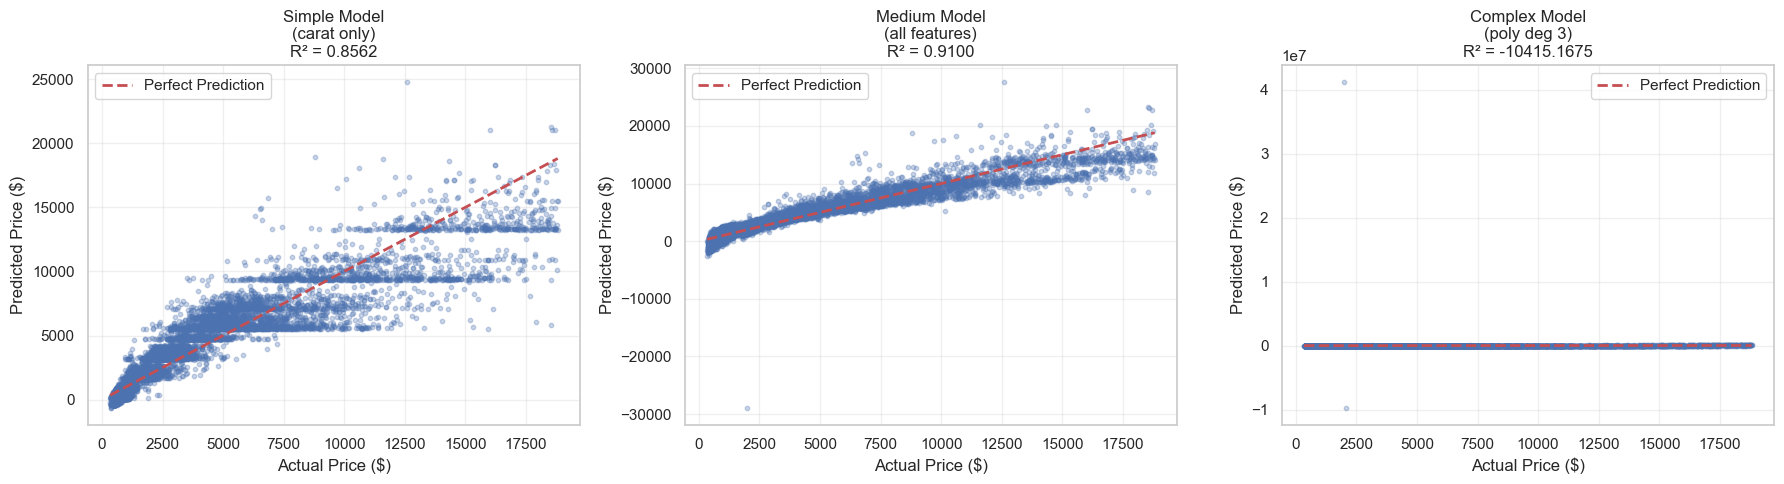

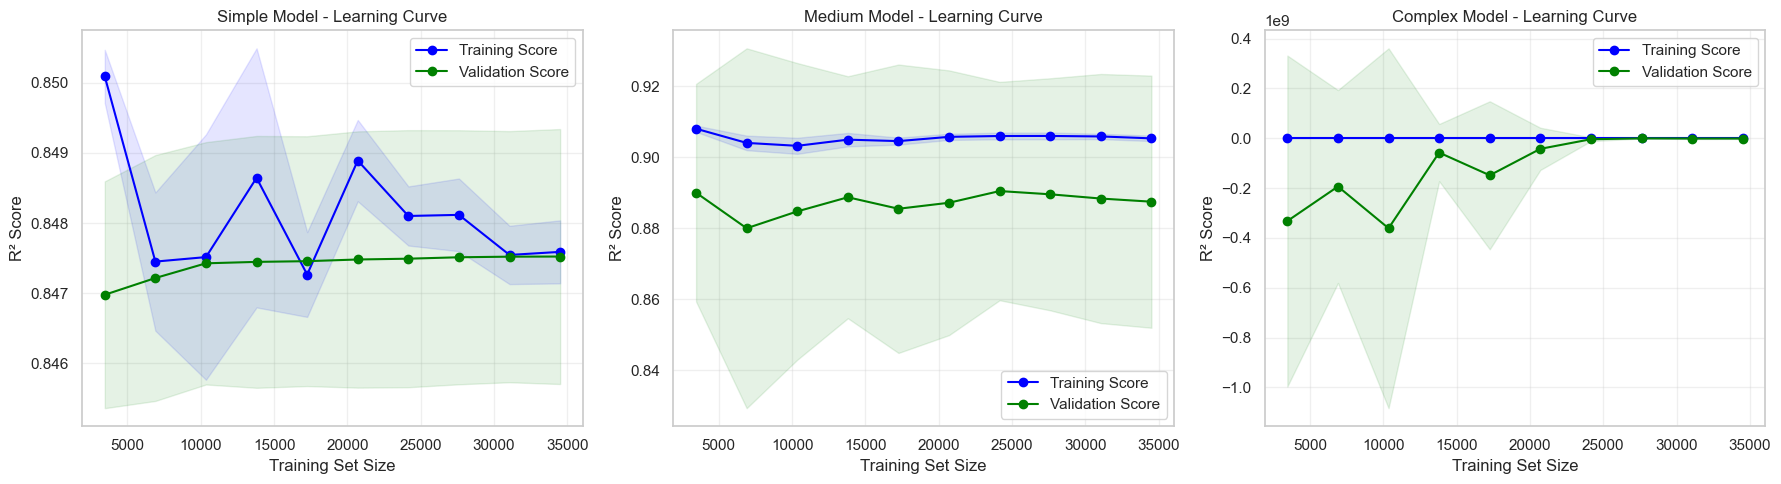


INTERPRETATION GUIDE

SIMPLE MODEL (Underfitting):
- High bias, low variance
- Too simple to capture diamond pricing patterns
- Both train and test scores are LOW
- Model didn't learn enough

MEDIUM MODEL (Good Fit):
- Balanced bias-variance
- Captures main patterns without memorizing noise
- Train and test scores are CLOSE
- This is what we want!

COMPLEX MODEL (Overfitting):
- Low bias, high variance
- Memorized training data including noise
- Train score HIGH, test score MUCH LOWER
- Gap shows how much it overfit

DIAMOND-SPECIFIC INSIGHT:
- Price vs Carat is NON-LINEAR (exponential)
- Simple linear model can't capture this curve
- Polynomial features CAN capture it but may overfit
- This is why boosting models (XGBoost) work better!



In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: LOAD & PREPARE DATA (You already have this)
# ============================================================

# Define features and target
X = df.drop('price', axis=1)
y = df['price']

# Identify column types
numerical_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']

# Ordinal encoding for categorical (preserves order: Fair < Good < Ideal)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']  # J=worst, D=best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]))
    ]), categorical_features)
])


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 60)
print("STEP 5: BIAS-VARIANCE DEMONSTRATION")
print("=" * 60)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# ============================================================
# MODEL 1: SIMPLE MODEL (Only Carat - High Bias, Low Variance)
# ============================================================
print("\n" + "=" * 60)
print("MODEL 1: SIMPLE MODEL (Only 'carat' feature)")
print("=" * 60)

# Use only carat
X_train_simple = X_train[['carat']]
X_test_simple = X_test[['carat']]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

# Predictions
simple_train_pred = simple_model.predict(X_train_simple)
simple_test_pred = simple_model.predict(X_test_simple)

# Metrics
simple_train_r2 = r2_score(y_train, simple_train_pred)
simple_test_r2 = r2_score(y_test, simple_test_pred)
simple_train_rmse = np.sqrt(mean_squared_error(y_train, simple_train_pred))
simple_test_rmse = np.sqrt(mean_squared_error(y_test, simple_test_pred))

print(f"Train R²:  {simple_train_r2:.4f}")
print(f"Test R²:   {simple_test_r2:.4f}")
print(f"Train RMSE: ${simple_train_rmse:.2f}")
print(f"Test RMSE:  ${simple_test_rmse:.2f}")
print(f"Gap:        {simple_train_r2 - simple_test_r2:.4f}")

# ============================================================
# MODEL 2: MEDIUM MODEL (All features - Balanced)
# ============================================================
print("\n" + "=" * 60)
print("MODEL 2: MEDIUM MODEL (All features, no polynomials)")
print("=" * 60)

medium_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

medium_pipeline.fit(X_train, y_train)

medium_train_pred = medium_pipeline.predict(X_train)
medium_test_pred = medium_pipeline.predict(X_test)

medium_train_r2 = r2_score(y_train, medium_train_pred)
medium_test_r2 = r2_score(y_test, medium_test_pred)
medium_train_rmse = np.sqrt(mean_squared_error(y_train, medium_train_pred))
medium_test_rmse = np.sqrt(mean_squared_error(y_test, medium_test_pred))

print(f"Train R²:  {medium_train_r2:.4f}")
print(f"Test R²:   {medium_test_r2:.4f}")
print(f"Train RMSE: ${medium_train_rmse:.2f}")
print(f"Test RMSE:  ${medium_test_rmse:.2f}")
print(f"Gap:        {medium_train_r2 - medium_test_r2:.4f}")

# ============================================================
# MODEL 3: COMPLEX MODEL (Polynomial Degree 3 - Low Bias, High Variance)
# ============================================================
print("\n" + "=" * 60)
print("MODEL 3: COMPLEX MODEL (Polynomial Features degree=3)")
print("=" * 60)

complex_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('regressor', LinearRegression())
])

complex_pipeline.fit(X_train, y_train)

complex_train_pred = complex_pipeline.predict(X_train)
complex_test_pred = complex_pipeline.predict(X_test)

complex_train_r2 = r2_score(y_train, complex_train_pred)
complex_test_r2 = r2_score(y_test, complex_test_pred)
complex_train_rmse = np.sqrt(mean_squared_error(y_train, complex_train_pred))
complex_test_rmse = np.sqrt(mean_squared_error(y_test, complex_test_pred))

print(f"Train R²:  {complex_train_r2:.4f}")
print(f"Test R²:   {complex_test_r2:.4f}")
print(f"Train RMSE: ${complex_train_rmse:.2f}")
print(f"Test RMSE:  ${complex_test_rmse:.2f}")
print(f"Gap:        {complex_train_r2 - complex_test_r2:.4f}")

# ============================================================
# COMPARISON TABLE
# ============================================================
print("\n" + "=" * 60)
print("COMPARISON TABLE")
print("=" * 60)

results = pd.DataFrame({
    'Model': ['Simple (carat only)', 'Medium (all features)', 'Complex (poly deg 3)'],
    'Train R²': [simple_train_r2, medium_train_r2, complex_train_r2],
    'Test R²': [simple_test_r2, medium_test_r2, complex_test_r2],
    'Train RMSE': [simple_train_rmse, medium_train_rmse, complex_train_rmse],
    'Test RMSE': [simple_test_rmse, medium_test_rmse, complex_test_rmse],
    'Gap (Train-Test)': [simple_train_r2 - simple_test_r2,
                         medium_train_r2 - medium_test_r2,
                         complex_train_r2 - complex_test_r2]
})

print(results.round(4))

# ============================================================
# VISUALIZATION 1: Score Comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# R² Comparison
x_pos = np.arange(len(results))
width = 0.35

axes[0].bar(x_pos - width/2, results['Train R²'], width, 
           label='Train R²', color='skyblue', edgecolor='black')
axes[0].bar(x_pos + width/2, results['Test R²'], width,
           label='Test R²', color='salmon', edgecolor='black')

axes[0].set_xlabel('Model Complexity', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Train vs Test R²: The Overfitting Story', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['Simple\n(Underfit)', 'Medium\n(Good)', 'Complex\n(Overfit)'])
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Add gap annotations
for i, gap in enumerate(results['Gap (Train-Test)']):
    axes[0].annotate(f'Gap: {gap:.3f}', 
                    xy=(i, max(results['Train R²'].iloc[i], results['Test R²'].iloc[i]) + 0.02),
                    ha='center', fontsize=10, color='red', fontweight='bold')

# RMSE Comparison
axes[1].bar(x_pos - width/2, results['Train RMSE'], width,
           label='Train RMSE', color='lightgreen', edgecolor='black')
axes[1].bar(x_pos + width/2, results['Test RMSE'], width,
           label='Test RMSE', color='orange', edgecolor='black')

axes[1].set_xlabel('Model Complexity', fontsize=12)
axes[1].set_ylabel('RMSE ($)', fontsize=12)
axes[1].set_title('Train vs Test RMSE: Error Analysis', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Simple\n(Underfit)', 'Medium\n(Good)', 'Complex\n(Overfit)'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/images/bias_variance_comparison.png', dpi=150, bbox_inches='tight') 
plt.show()

# ============================================================
# VISUALIZATION 2: Actual vs Predicted for Each Model
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    ('Simple Model\n(carat only)', simple_test_pred, simple_test_r2),
    ('Medium Model\n(all features)', medium_test_pred, medium_test_r2),
    ('Complex Model\n(poly deg 3)', complex_test_pred, complex_test_r2)
]

for idx, (title, pred, score) in enumerate(models_data):
    axes[idx].scatter(y_test, pred, alpha=0.3, s=10)
    axes[idx].plot([y_test.min(), y_test.max()], 
                  [y_test.min(), y_test.max()], 
                  'r--', lw=2, label='Perfect Prediction')
    axes[idx].set_xlabel('Actual Price ($)')
    axes[idx].set_ylabel('Predicted Price ($)')
    axes[idx].set_title(f'{title}\nR² = {score:.4f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/images/actual_vs_predicted_bias_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALIZATION 3: Learning Curves (Bonus)
# ============================================================
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_for_curve = [
    ('Simple', LinearRegression(), X_train_simple),
    ('Medium', Pipeline([('preprocessor', preprocessor), 
                        ('regressor', LinearRegression())]), X_train),
    ('Complex', Pipeline([('preprocessor', preprocessor),
                          ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                          ('regressor', LinearRegression())]), X_train)
]

for idx, (name, model, X_data) in enumerate(models_for_curve):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_data, y_train, cv=5, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)
    
    axes[idx].plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    axes[idx].plot(train_sizes, test_mean, 'o-', color='green', label='Validation Score')
    axes[idx].fill_between(train_sizes, train_mean - train_scores.std(axis=1),
                          train_mean + train_scores.std(axis=1), alpha=0.1, color='blue')
    axes[idx].fill_between(train_sizes, test_mean - test_scores.std(axis=1),
                          test_mean + test_scores.std(axis=1), alpha=0.1, color='green')
    axes[idx].set_xlabel('Training Set Size')
    axes[idx].set_ylabel('R² Score')
    axes[idx].set_title(f'{name} Model - Learning Curve')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/images/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# INTERPRETATION GUIDE
# ============================================================
print("\n" + "=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)

print("""
SIMPLE MODEL (Underfitting):
- High bias, low variance
- Too simple to capture diamond pricing patterns
- Both train and test scores are LOW
- Model didn't learn enough

MEDIUM MODEL (Good Fit):
- Balanced bias-variance
- Captures main patterns without memorizing noise
- Train and test scores are CLOSE
- This is what we want!

COMPLEX MODEL (Overfitting):
- Low bias, high variance
- Memorized training data including noise
- Train score HIGH, test score MUCH LOWER
- Gap shows how much it overfit

DIAMOND-SPECIFIC INSIGHT:
- Price vs Carat is NON-LINEAR (exponential)
- Simple linear model can't capture this curve
- Polynomial features CAN capture it but may overfit
- This is why boosting models (XGBoost) work better!
""")

print("=" * 60)

The primary issue is a massive **Overfitting** problem in the **Complex Model (Model 3).**

### The Error/Problem Identified

In the cell titled "MODEL 3: COMPLEX MODEL (Polynomial Features degree=3)", the output metrics reveal a catastrophic failure:

- Train $R^2$: 0.9775 (Appears to perform perfectly on training data)
- Test $R^2$: -10415.1675 (A negative $R^2$ indicates the model is significantly worse than a horizontal line)
- Test RMSE: $408,645.92 (Compared to a Training RMSE of only $597.48)

### What is the issue?

The issue is **High Variance (Extreme Overfitting)** caused by excessive model complexity. Specifically:

1. **Degree-3 Polynomial Features**: By applying a 3rd-degree polynomial transformation to all features without regularization, the model created an enormous number of feature interactions.
2. **Noise Memorization**: The model "memorized" the specific noise and outliers in the training dataset instead of learning the underlying trend of diamond pricing.
3. **Numerical Instability**: In linear regression, such high-degree polynomials often lead to massive coefficients, causing predictions to "explode" when encountering test data slightly different from the training set.

### Comparison Summary

| Model                 | Train $R^2$ | Test $R^2$   | Status                          |
|-----------------------|-------------|--------------|---------------------------------|
| Simple (Carat only)   | 0.8476      | 0.8562       | Underfitting (High Bias)        |
| Medium (All features) | 0.9052      | 0.9100       | Good Fit (Balanced)             |
| Complex (Poly deg 3)  | 0.9775      | -10415.1675  | Overfitting (High Variance)     |

### Recommendation

To fix this, you should either reduce the polynomial degree to 2, use feature selection to limit interactions, or apply Regularization techniques like Ridge or Lasso regression to penalize large coefficients.

TOP FEATURE COEFFICIENTS (Medium Model - R² = 0.91)
        Feature  Coefficient  Abs_Coefficient
          carat  5119.263445      5119.263445
              z  -757.251967       757.251967
clarity_ordinal   499.478749       499.478749
              x  -387.434156       387.434156
  color_ordinal   323.027896       323.027896
              y   153.951503       153.951503
    cut_ordinal   128.290332       128.290332
          table   -55.320798        55.320798
          depth   -22.637478        22.637478


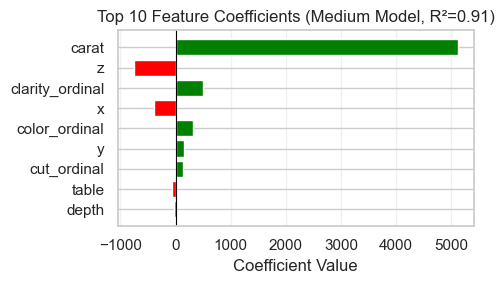


INTERPRETATION

- Positive coefficient → as feature increases, predicted price increases.
- Negative coefficient → as feature increases, predicted price decreases.
- Absolute value → strength of influence.

For diamond pricing:
  * 'carat' should have a large positive coefficient (heavier → more expensive).
  * 'clarity_ordinal' (higher = better clarity) should be positive.
  * 'color_ordinal' (higher = better color, i.e., D=7) should be positive.
  * 'cut_ordinal' (higher = better cut) should be positive.
  * 'depth' or 'table' might be negative if optimal ranges exist.




In [59]:
# ============================================================
# EXTRACT FEATURE COEFFICIENTS FROM MEDIUM MODEL
# ============================================================

# Step 1: Get the fitted regressor from the pipeline
linear_reg = medium_pipeline.named_steps['regressor']
coefficients = linear_reg.coef_

# Step 2: Get feature names after preprocessing
# The preprocessor is a ColumnTransformer; we need to get names from each transformer

# For numerical features (after scaling, names unchanged)
num_features = numerical_features  # ['carat', 'depth', 'table', 'x', 'y', 'z']

# For categorical features (ordinal encoded, one column per original feature)
# The OrdinalEncoder outputs 3 columns (cut, color, clarity) in that order
cat_features = ['cut_ordinal', 'color_ordinal', 'clarity_ordinal']  # custom names

# Combine all feature names in the order the preprocessor outputs them
# The ColumnTransformer concatenates: first 'num', then 'cat'
all_feature_names = num_features + cat_features

# Step 3: Create a DataFrame of coefficients
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient (largest impact)
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("=" * 60)
print("TOP FEATURE COEFFICIENTS (Medium Model - R² = 0.91)")
print("=" * 60)
print(coef_df.to_string(index=False))

# Step 4: Visualize top 10 coefficients (positive and negative)
top_n = 10
top_features = coef_df.head(top_n)

plt.figure(figsize=(5, 3))
colors = ['red' if c < 0 else 'green' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title(f'Top {top_n} Feature Coefficients (Medium Model, R²=0.91)')
plt.gca().invert_yaxis()  # highest at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Step 5: Explanation of what these coefficients mean
print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print("""
- Positive coefficient → as feature increases, predicted price increases.
- Negative coefficient → as feature increases, predicted price decreases.
- Absolute value → strength of influence.

For diamond pricing:
  * 'carat' should have a large positive coefficient (heavier → more expensive).
  * 'clarity_ordinal' (higher = better clarity) should be positive.
  * 'color_ordinal' (higher = better color, i.e., D=7) should be positive.
  * 'cut_ordinal' (higher = better cut) should be positive.
  * 'depth' or 'table' might be negative if optimal ranges exist.

""")

### Cross-Validation

| Single Split                    | Cross-Validation             |
| ------------------------------- | ---------------------------- |
| One train-test pair             | Multiple train-test pairs    |
| Result depends on random chance | Average of many results      |
| Might be lucky/unlucky split    | Shows true performance range |
| **Unreliable**                  | **Reliable**                 |

STEP 6: CROSS-VALIDATION (K-FOLD)
Training samples: 43136

PART 1: WHY CV BEATS SINGLE SPLIT

❌ SINGLE SPLIT RESULT:
   Test R²: 0.9764
   Problem: This is just ONE random split!
   What if we got lucky/unlucky with this split?

✅ CROSS-VALIDATION RESULT:
   5 CV Scores: [0.97651748 0.97572527 0.97569716 0.97627904 0.97444052]
   Mean CV R²:  0.9757
   Std Dev:     0.0007
   95% Range:   0.9743 to 0.9772

📊 COMPARISON:
   Single Split: 0.9764
   CV Mean:      0.9757
   Difference:   0.0007

PART 2: VISUALIZING CV STABILITY


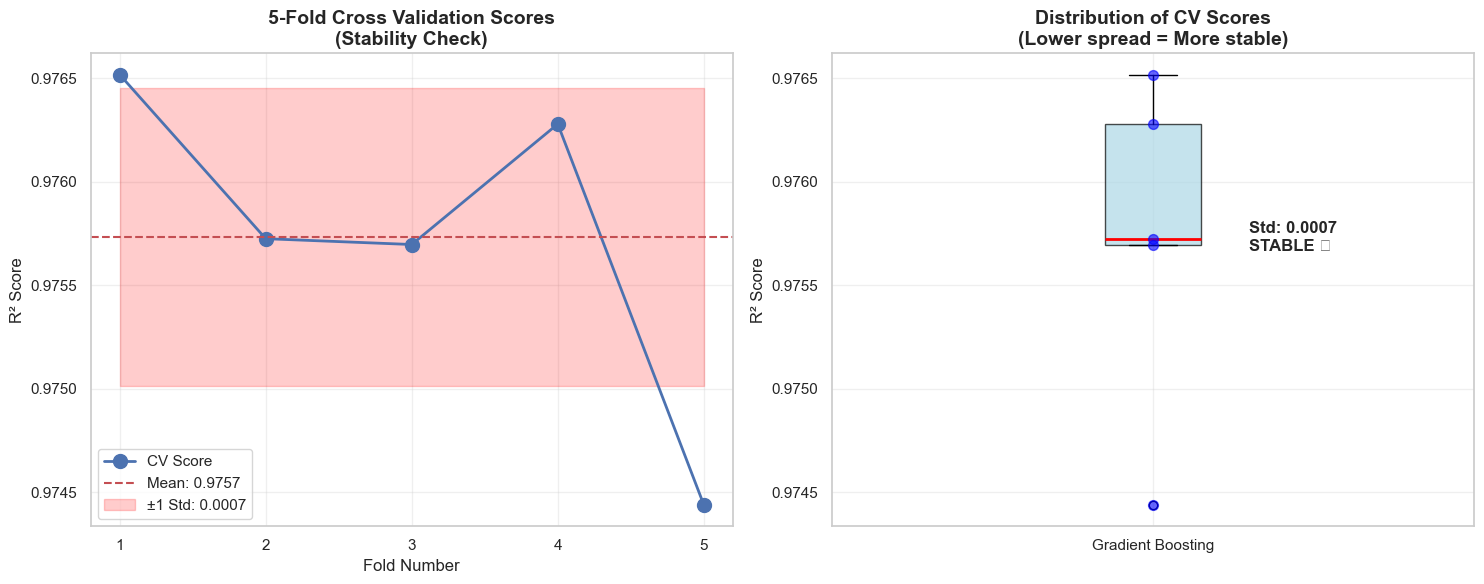


PART 3: MODEL COMPARISON USING CV

Linear Regression:
   Mean: 0.8875 (+/- 0.0355)
   Range: [0.8167, 0.9088]

Ridge (alpha=10):
   Mean: 0.8942 (+/- 0.0222)
   Range: [0.8500, 0.9087]

Lasso (alpha=100):
   Mean: 0.8998 (+/- 0.0019)
   Range: [0.8972, 0.9028]

Gradient Boosting:
   Mean: 0.9757 (+/- 0.0007)
   Range: [0.9744, 0.9765]

XGBoost:
   Mean: 0.9804 (+/- 0.0005)
   Range: [0.9798, 0.9811]

CV COMPARISON TABLE
            Model  CV Mean R²  CV Std  Min Score  Max Score  Stability
Linear Regression      0.8875  0.0355     0.8167     0.9088 Unstable ❌
 Ridge (alpha=10)      0.8942  0.0222     0.8500     0.9087 Unstable ❌
Lasso (alpha=100)      0.8998  0.0019     0.8972     0.9028   Stable ✅
Gradient Boosting      0.9757  0.0007     0.9744     0.9765   Stable ✅
          XGBoost      0.9804  0.0005     0.9798     0.9811   Stable ✅


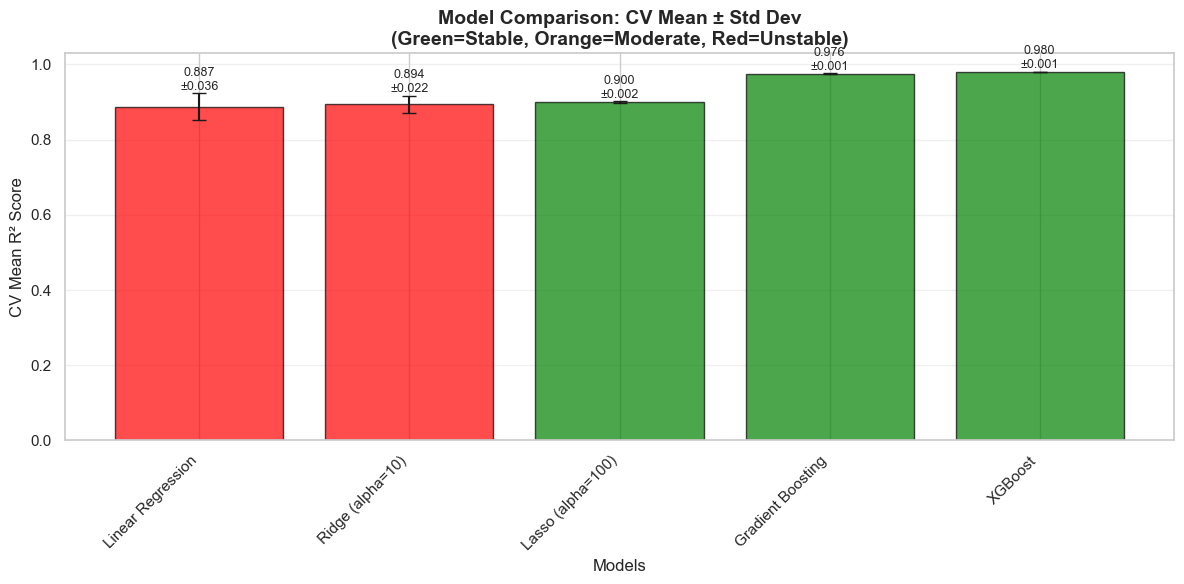


PART 5: CHOOSING K (Number of Folds)
K=3: Mean=0.9755, Std=0.0004
K=5: Mean=0.9757, Std=0.0007
K=10: Mean=0.9759, Std=0.0014

 K  Mean R²      Std   Time
 3 0.975499 0.000372   Fast
 5 0.975732 0.000719 Medium
10 0.975862 0.001354   Slow

📊 K-FOLD GUIDE:
   K=3:  Fast, less reliable (small data)
   K=5:  Balanced (standard choice)
   K=10: More reliable, slower (recommended for final evaluation)
   K=N:  Leave-One-Out (very slow, use only for tiny datasets)


PART 6: FINAL VERIFICATION (Test Set)
CV Mean R² (training): 0.9757
Test R² (unseen):      0.9764
Difference:            0.0007

✅ Model generalizes well! CV was honest.

STUDENT INTERPRETATION GUIDE

🔍 HOW TO READ CV RESULTS:

1. HIGH MEAN + LOW STD = PERFECT MODEL ✅
   Example: 0.95 ± 0.002
   → Consistently excellent across all folds

2. HIGH MEAN + HIGH STD = UNSTABLE MODEL ⚠️
   Example: 0.95 ± 0.05
   → Sometimes great, sometimes terrible
   → Model is sensitive to data variations

3. LOW MEAN + LOW STD = BAD BUT CONSISTENT

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, make_scorer
import warnings
warnings.filterwarnings('ignore')
# ============================================================
# LOAD & PREPARE DATA (Same as before)
# ============================================================
print("=" * 60)
print("STEP 6: CROSS-VALIDATION (K-FOLD)")
print("=" * 60)
print(f"Training samples: {len(X_train)}")

# ============================================================
# PART 1: SINGLE SPLIT vs CROSS-VALIDATION COMPARISON
# ============================================================
print("\n" + "=" * 60)
print("PART 1: WHY CV BEATS SINGLE SPLIT")
print("=" * 60)

# Create your best pipeline from previous step
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

# Method 1: Single Split Score
best_pipeline.fit(X_train, y_train)
single_split_score = r2_score(y_test, best_pipeline.predict(X_test))

print(f"\n❌ SINGLE SPLIT RESULT:")
print(f"   Test R²: {single_split_score:.4f}")
print(f"   Problem: This is just ONE random split!")
print(f"   What if we got lucky/unlucky with this split?")

# Method 2: Cross-Validation (the right way)
print(f"\n✅ CROSS-VALIDATION RESULT:")

cv_scores = cross_val_score(
    best_pipeline,      # Your model pipeline
    X_train,            # Training data only!
    y_train,            # Training target only!
    cv=5,               # 5 folds
    scoring='r2',       # R² metric
    n_jobs=-1           # Use all CPU cores
)

print(f"   5 CV Scores: {cv_scores}")
print(f"   Mean CV R²:  {cv_scores.mean():.4f}")
print(f"   Std Dev:     {cv_scores.std():.4f}")
print(f"   95% Range:   {cv_scores.mean() - 2*cv_scores.std():.4f} to {cv_scores.mean() + 2*cv_scores.std():.4f}")

print(f"\n📊 COMPARISON:")
print(f"   Single Split: {single_split_score:.4f}")
print(f"   CV Mean:      {cv_scores.mean():.4f}")
print(f"   Difference:   {abs(single_split_score - cv_scores.mean()):.4f}")

# ============================================================
# PART 2: VISUALIZE CV STABILITY
# ============================================================
print("\n" + "=" * 60)
print("PART 2: VISUALIZING CV STABILITY")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: CV Scores with mean line
axes[0].plot(range(1, 6), cv_scores, 'bo-', linewidth=2, markersize=10, label='CV Score')
axes[0].axhline(y=cv_scores.mean(), color='r', linestyle='--', 
               label=f'Mean: {cv_scores.mean():.4f}')
axes[0].fill_between(range(1, 6), 
                    cv_scores.mean() - cv_scores.std(),
                    cv_scores.mean() + cv_scores.std(),
                    alpha=0.2, color='red', label=f'±1 Std: {cv_scores.std():.4f}')
axes[0].set_xlabel('Fold Number', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('5-Fold Cross Validation Scores\n(Stability Check)', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 6))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot of CV scores
axes[1].boxplot(cv_scores, vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
axes[1].scatter([1]*5, cv_scores, color='blue', alpha=0.6, s=50, zorder=3)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Distribution of CV Scores\n(Lower spread = More stable)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Gradient Boosting'])
axes[1].grid(True, alpha=0.3)

# Add text annotation
stability_text = "STABLE ✅" if cv_scores.std() < 0.01 else "MODERATE ⚠️" if cv_scores.std() < 0.02 else "UNSTABLE ❌"
axes[1].text(1.15, cv_scores.mean(), f'Std: {cv_scores.std():.4f}\n{stability_text}', 
            fontsize=12, fontweight='bold', va='center')

plt.tight_layout()
plt.savefig('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/images/cross_validation_stability.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PART 3: COMPARE MULTIPLE MODELS WITH CV
# ============================================================
print("\n" + "=" * 60)
print("PART 3: MODEL COMPARISON USING CV")
print("=" * 60)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=10),
    'Lasso (alpha=100)': Lasso(alpha=100),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42)
}

cv_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # 5-Fold CV
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    
    cv_results.append({
        'Model': name,
        'CV Mean R²': scores.mean(),
        'CV Std': scores.std(),
        'Min Score': scores.min(),
        'Max Score': scores.max(),
        'Stability': 'Stable ✅' if scores.std() < 0.01 else 'Moderate ⚠️' if scores.std() < 0.02 else 'Unstable ❌'
    })
    
    print(f"\n{name}:")
    print(f"   Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"   Range: [{scores.min():.4f}, {scores.max():.4f}]")

cv_df = pd.DataFrame(cv_results)
print("\n" + "=" * 60)
print("CV COMPARISON TABLE")
print("=" * 60)
print(cv_df.round(4).to_string(index=False))

# ============================================================
# PART 4: VISUALIZE MODEL COMPARISON
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(cv_df))
colors = ['red' if 'Unstable' in s else 'orange' if 'Moderate' in s else 'green' 
          for s in cv_df['Stability']]

bars = ax.bar(x_pos, cv_df['CV Mean R²'], yerr=cv_df['CV Std'], 
             capsize=5, color=colors, alpha=0.7, edgecolor='black')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('CV Mean R² Score', fontsize=12)
ax.set_title('Model Comparison: CV Mean ± Std Dev\n(Green=Stable, Orange=Moderate, Red=Unstable)', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Model'], rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, mean, std in zip(bars, cv_df['CV Mean R²'], cv_df['CV Std']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.002,
           f'{mean:.3f}\n±{std:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/images/cv_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PART 5: DIFFERENT K VALUES (How many folds?)
# ============================================================
print("\n" + "=" * 60)
print("PART 5: CHOOSING K (Number of Folds)")
print("=" * 60)

k_values = [3, 5, 10]
k_results = []

for k in k_values:
    scores = cross_val_score(best_pipeline, X_train, y_train, cv=k, scoring='r2')
    k_results.append({
        'K': k,
        'Mean R²': scores.mean(),
        'Std': scores.std(),
        'Time': 'Fast' if k == 3 else 'Medium' if k == 5 else 'Slow'
    })
    print(f"K={k}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

k_df = pd.DataFrame(k_results)
print(f"\n{k_df.to_string(index=False)}")

print("""
📊 K-FOLD GUIDE:
   K=3:  Fast, less reliable (small data)
   K=5:  Balanced (standard choice)
   K=10: More reliable, slower (recommended for final evaluation)
   K=N:  Leave-One-Out (very slow, use only for tiny datasets)
""")

# ============================================================
# PART 6: VERIFY WITH HELD-OUT TEST SET
# ============================================================
print("\n" + "=" * 60)
print("PART 6: FINAL VERIFICATION (Test Set)")
print("=" * 60)

# Train on FULL training data
best_pipeline.fit(X_train, y_train)

# Evaluate on completely unseen test data
test_pred = best_pipeline.predict(X_test)
test_r2 = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"CV Mean R² (training): {cv_scores.mean():.4f}")
print(f"Test R² (unseen):      {test_r2:.4f}")
print(f"Difference:            {abs(cv_scores.mean() - test_r2):.4f}")

if abs(cv_scores.mean() - test_r2) < 0.02:
    print("\n✅ Model generalizes well! CV was honest.")
else:
    print("\n⚠️ Warning: Test score differs from CV. Possible overfitting.")

# ============================================================
# INTERPRETATION GUIDE
# ============================================================
print("\n" + "=" * 60)
print("STUDENT INTERPRETATION GUIDE")
print("=" * 60)

print("""
🔍 HOW TO READ CV RESULTS:

1. HIGH MEAN + LOW STD = PERFECT MODEL ✅
   Example: 0.95 ± 0.002
   → Consistently excellent across all folds

2. HIGH MEAN + HIGH STD = UNSTABLE MODEL ⚠️
   Example: 0.95 ± 0.05
   → Sometimes great, sometimes terrible
   → Model is sensitive to data variations

3. LOW MEAN + LOW STD = BAD BUT CONSISTENT ❌
   Example: 0.60 ± 0.005
   → Always mediocre, never good
   → Model is too simple (underfitting)

4. LOW MEAN + HIGH STD = TERRIBLE MODEL ❌❌
   Example: 0.60 ± 0.08
   → Unreliable and inaccurate

FOR DIAMONDS:
   - CV Std < 0.01 → Very stable (good!)
   - CV Std 0.01-0.02 → Acceptable
   - CV Std > 0.02 → Investigate (maybe outliers?)

WHY THIS MATTERS:
   Single split might show R² = 0.98 by luck.
   CV shows R² = 0.92 ± 0.03 = true performance.
   Always trust CV over single split!
""")

###  Regularization (Fix Overfitting) 
Following Variations of the standard linear regression algorithm (Models) :

 Ridge Regression

 Lasso Regression

 Elastic Net

| Problem            | Cause                   | Solution                                    |
| ------------------ | ----------------------- | ------------------------------------------- |
| Overfitting        | Coefficients too large  | **Ridge** (L2): Shrinks all coefficients    |
| Too many features  | Some features are noise | **Lasso** (L1): Forces some to exactly zero |
| Need both benefits | Complex data with noise | **ElasticNet**: Combines L1 + L2            |

STEP 7: REGULARIZATION (Ridge, Lasso, ElasticNet)

PART 1: BASELINE - LINEAR REGRESSION (No Regularization)
Number of features: 9
Number of non-zero coefficients: 9

Coefficients:
   carat          :    5119.26
   depth          :     -22.64
   table          :     -55.32
   x              :    -387.43
   y              :     153.95
   z              :    -757.25
   cut            :     128.29
   color          :     323.03
   clarity        :     499.48

Train R²: 0.9052
Test R²:  0.9100
Gap:      -0.0048

PART 2: RIDGE REGRESSION (L2 Penalty)
Effect: Shrinks ALL coefficients toward zero, but NEVER to exactly zero
Formula: Loss = MSE + alpha × Σ(coefficient²)
   Alpha  CV Mean R²  CV Std  Coef Sum (abs)  Max Coef  Non-zero Coefs
   0.001      0.8875  0.0355       7446.6488 5119.2602               9
   0.010      0.8875  0.0355       7446.5807 5119.2311               9
   0.100      0.8876  0.0353       7445.9005 5118.9401               9
   1.000      0.8884  0.0337       7439.1073 51

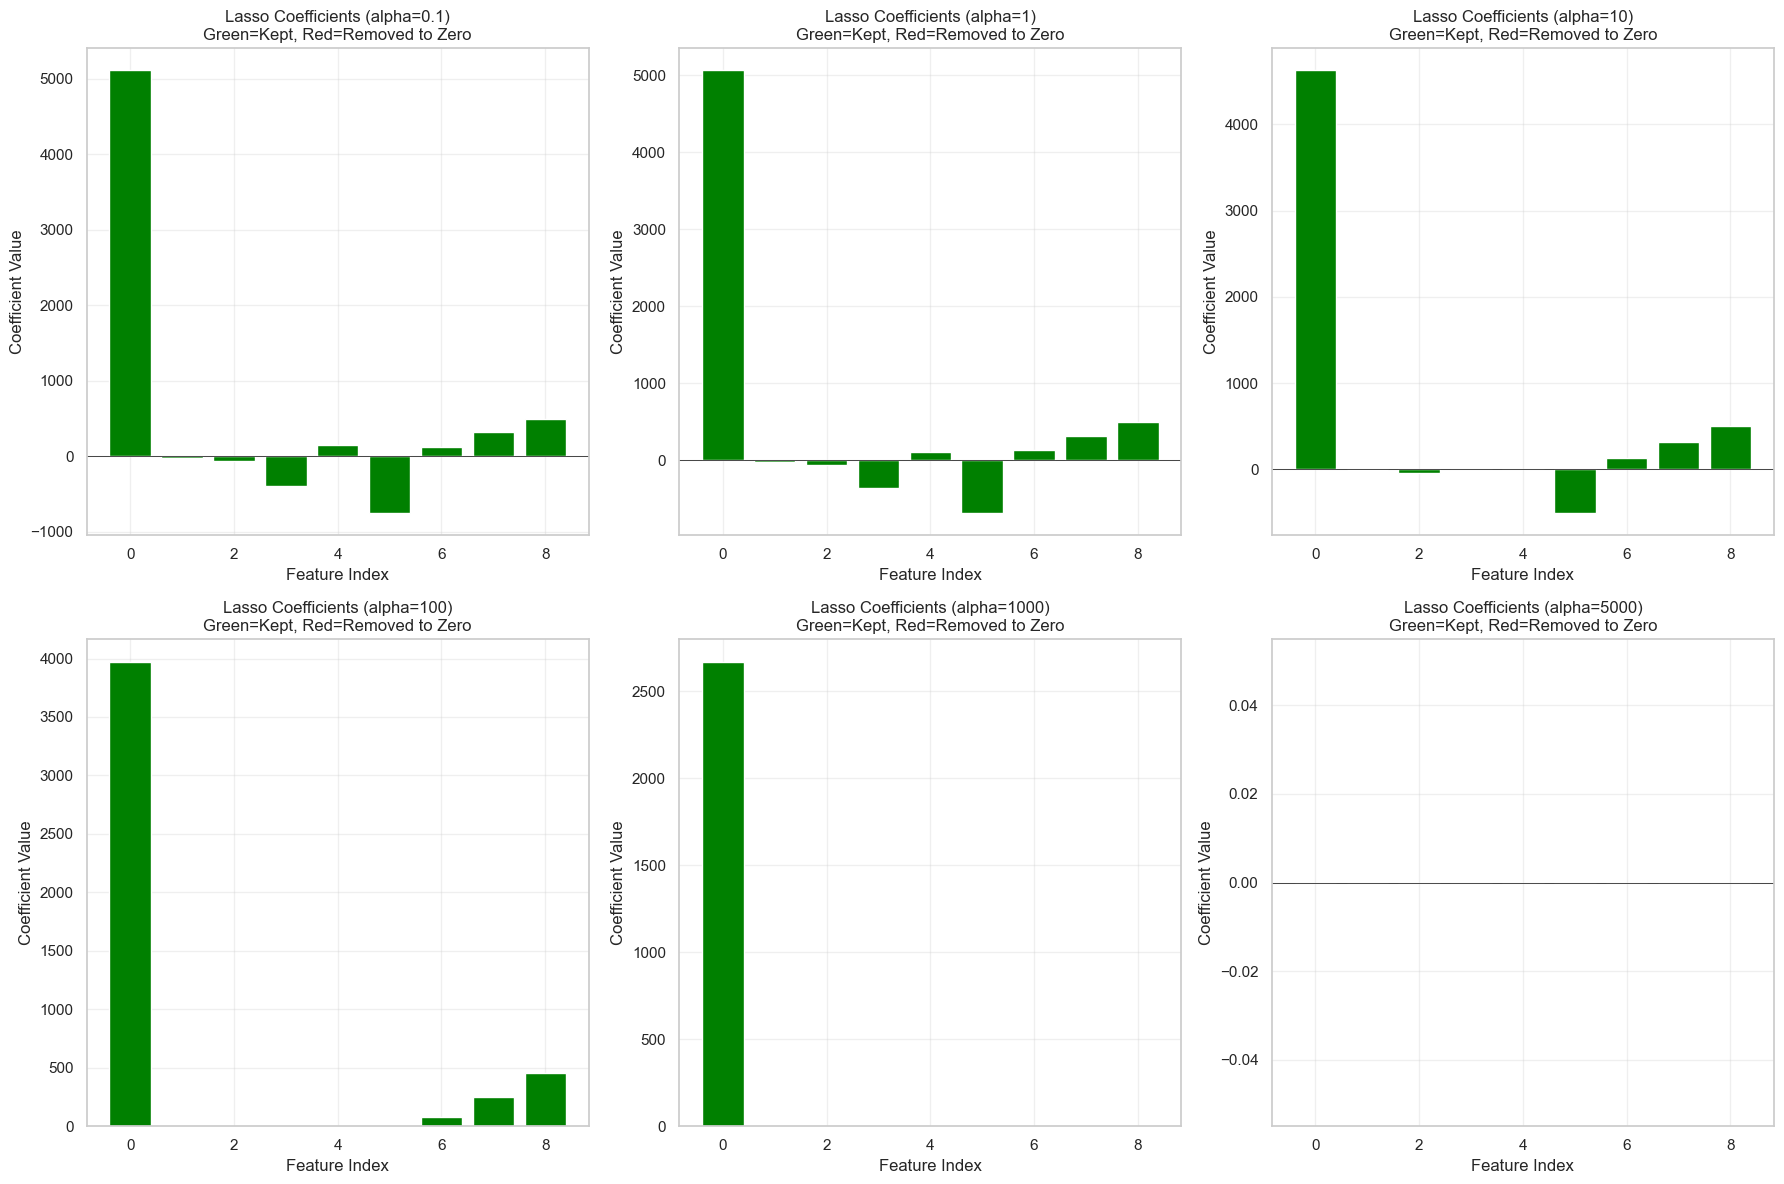


Best Lasso alpha: 10.0


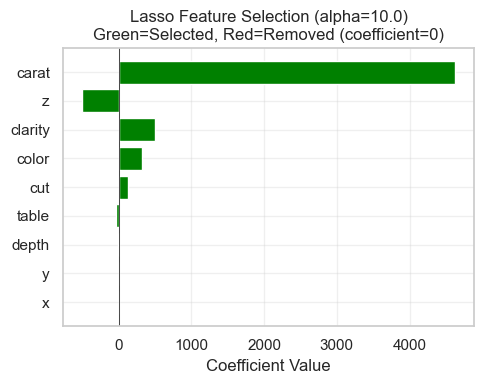


Features selected by Lasso (alpha=10.0):
Feature  Coefficient
  depth   -12.282842
  table   -38.160738
    cut   129.451830
  color   314.313194
clarity   503.469468
      z  -507.496343
  carat  4628.546632

Features REMOVED by Lasso (coefficient = 0):
Feature
      x
      y

PART 5: ELASTIC NET (L1 + L2 Combined)
Effect: Gets best of both worlds - feature selection + stable coefficients
Formula: Loss = MSE + alpha × [l1_ratio × Σ|coef| + (1-l1_ratio) × Σ(coef²)]
 Alpha  L1_ratio  CV Mean R²  Non-zero Coefs  Zero Coefs
   0.1       0.1      0.8794               9           0
   0.1       0.5      0.8878               9           0
   0.1       0.7      0.8941               9           0
   0.1       0.9      0.9021               9           0
   1.0       0.1      0.8133               9           0
   1.0       0.5      0.8445               9           0
   1.0       0.7      0.8593               9           0
   1.0       0.9      0.8779               9           0
  10.0       0.

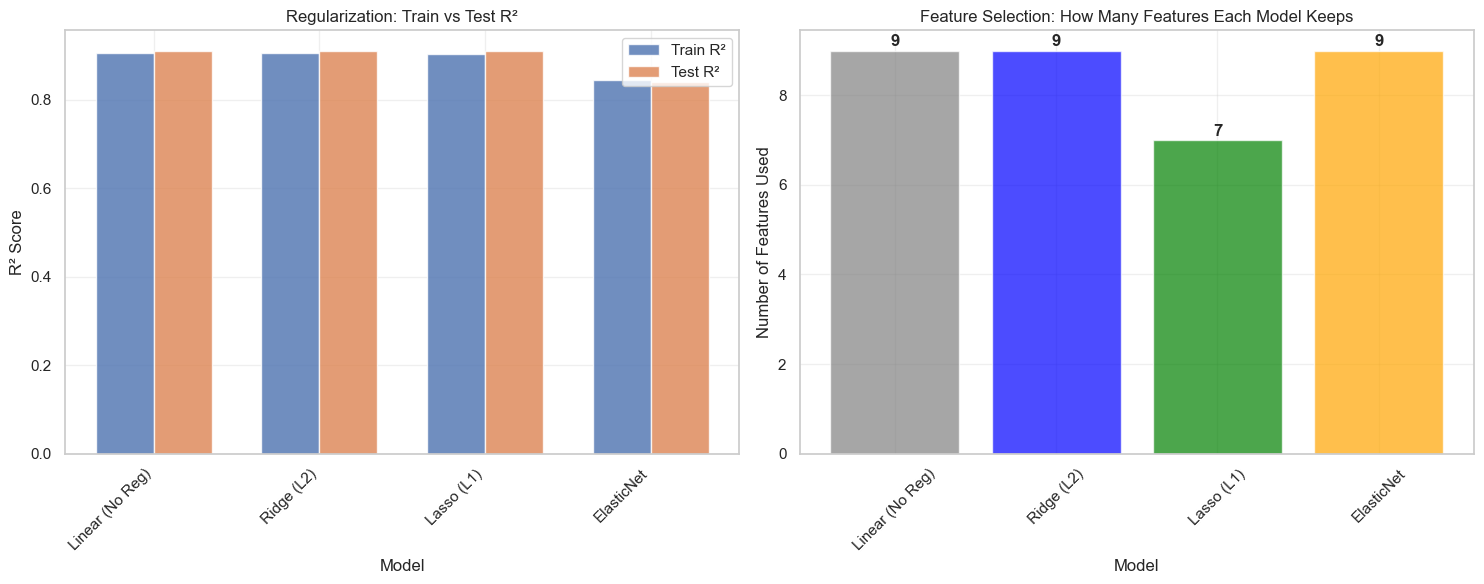


🎓 STUDENT INTERPRETATION GUIDE

WHAT YOU JUST LEARNED:

1. LINEAR REGRESSION (No Regularization)
   - Uses ALL features
   - Coefficients can be very large
   - Risk: Overfitting on noisy features

2. RIDGE (L2 Penalty) - "The Shrinker"
   - Formula: MSE + alpha × Σ(coef²)
   - Effect: Makes all coefficients SMALLER
   - NEVER sets coefficients to exactly zero
   - Good for: Handling multicollinearity (correlated features)

3. LASSO (L1 Penalty) - "The Selector" ⭐
   - Formula: MSE + alpha × Σ|coef|
   - Effect: Forces SOME coefficients to EXACTLY ZERO
   - Good for: Automatic feature selection!
   - Key insight: If coef = 0, that feature doesn't matter

4. ELASTIC NET - "The Hybrid"
   - Formula: MSE + alpha × [L1_part + L2_part]
   - Effect: Both shrinks AND selects features
   - Good for: When you have many correlated features

FOR DIAMONDS SPECIFICALLY:
   - Carat will ALWAYS have large coefficient (most important)
   - Lasso might zero out 'table' or 'depth' if they're less impor

In [65]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# ============================================================
# LOAD & PREPARE DATA
# ============================================================
X = df.drop('price', axis=1)
y = df['price']

numerical_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']

cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]))
    ]), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=" * 70)
print("STEP 7: REGULARIZATION (Ridge, Lasso, ElasticNet)")
print("=" * 70)

# ============================================================
# PART 1: BASELINE (No Regularization)
# ============================================================
print("\n" + "=" * 70)
print("PART 1: BASELINE - LINEAR REGRESSION (No Regularization)")
print("=" * 70)

baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

baseline.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = (numerical_features + 
                list(preprocessor.named_transformers_['cat']
                    .named_steps['ordinal']
                    .get_feature_names_out(categorical_features)))

baseline_coefs = baseline.named_steps['regressor'].coef_

print(f"Number of features: {len(feature_names)}")
print(f"Number of non-zero coefficients: {np.sum(baseline_coefs != 0)}")
print(f"\nCoefficients:")
for name, coef in zip(feature_names, baseline_coefs):
    print(f"   {name:15s}: {coef:10.2f}")

baseline_train_r2 = r2_score(y_train, baseline.predict(X_train))
baseline_test_r2 = r2_score(y_test, baseline.predict(X_test))
print(f"\nTrain R²: {baseline_train_r2:.4f}")
print(f"Test R²:  {baseline_test_r2:.4f}")
print(f"Gap:      {baseline_train_r2 - baseline_test_r2:.4f}")

# ============================================================
# PART 2: RIDGE REGRESSION (L2 Penalty)
# ============================================================
print("\n" + "=" * 70)
print("PART 2: RIDGE REGRESSION (L2 Penalty)")
print("=" * 70)
print("Effect: Shrinks ALL coefficients toward zero, but NEVER to exactly zero")
print("Formula: Loss = MSE + alpha × Σ(coefficient²)")

ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for alpha in ridge_alphas:
    ridge = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=alpha))
    ])
    
    ridge.fit(X_train, y_train)
    coefs = ridge.named_steps['regressor'].coef_
    
    # Cross-validation score
    cv_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
    
    ridge_results.append({
        'Alpha': alpha,
        'CV Mean R²': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Coef Sum (abs)': np.sum(np.abs(coefs)),
        'Max Coef': np.max(np.abs(coefs)),
        'Non-zero Coefs': np.sum(coefs != 0)
    })

ridge_df = pd.DataFrame(ridge_results)
print(ridge_df.round(4).to_string(index=False))

# ============================================================
# PART 3: LASSO REGRESSION (L1 Penalty) ⭐ KEY LEARNING
# ============================================================
print("\n" + "=" * 70)
print("PART 3: LASSO REGRESSION (L1 Penalty) ⭐ AUTOMATIC FEATURE SELECTION")
print("=" * 70)
print("Effect: Forces SOME coefficients to EXACTLY ZERO")
print("Formula: Loss = MSE + alpha × Σ|coefficient|")
print("\n🎯 THIS IS THE MAGIC: Lasso tells you which features matter!")

lasso_alphas = [0.1, 1, 10, 100, 500, 1000, 5000]
lasso_results = []

for alpha in lasso_alphas:
    lasso = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=alpha, max_iter=10000))
    ])
    
    lasso.fit(X_train, y_train)
    coefs = lasso.named_steps['regressor'].coef_
    
    # Cross-validation score
    cv_scores = cross_val_score(lasso, X_train, y_train, cv=5, scoring='r2')
    
    # Count zero coefficients (THIS IS THE KEY!)
    zero_coefs = np.sum(coefs == 0)
    non_zero_coefs = np.sum(coefs != 0)
    
    lasso_results.append({
        'Alpha': alpha,
        'CV Mean R²': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Non-zero Coefs': non_zero_coefs,
        'Zero Coefs': zero_coefs,
        'Features Kept (%)': (non_zero_coefs / len(coefs)) * 100
    })

lasso_df = pd.DataFrame(lasso_results)
print(lasso_df.round(4).to_string(index=False))

print(f"\n📊 LASSO FEATURE SELECTION RESULTS:")
print(f"Total features: {len(feature_names)}")
for _, row in lasso_df.iterrows():
    print(f"Alpha={row['Alpha']:6.1f}: Keeps {int(row['Non-zero Coefs'])} features, "
          f"removes {int(row['Zero Coefs'])} features")

# ============================================================
# PART 4: VISUALIZE LASSO FEATURE SELECTION
# ============================================================
print("\n" + "=" * 70)
print("PART 4: VISUALIZING LASSO FEATURE SELECTION")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Coefficient paths for different alphas
alphas_to_plot = [0.1, 1, 10, 100, 1000, 5000]
colors = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))

for idx, alpha in enumerate(alphas_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    lasso = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=alpha, max_iter=10000))
    ])
    lasso.fit(X_train, y_train)
    coefs = lasso.named_steps['regressor'].coef_
    
    # Bar plot of coefficients
    bars = ax.bar(range(len(coefs)), coefs, color=['red' if c == 0 else 'green' for c in coefs])
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Coefficient Value')
    ax.set_title(f'Lasso Coefficients (alpha={alpha})\n'
                f'Green=Kept, Red=Removed to Zero')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/images/lasso_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Feature importance for best Lasso
best_alpha = lasso_df.loc[lasso_df['CV Mean R²'].idxmax(), 'Alpha']
print(f"\nBest Lasso alpha: {best_alpha}")

best_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=best_alpha, max_iter=10000))
])
best_lasso.fit(X_train, y_train)
best_coefs = best_lasso.named_steps['regressor'].coef_

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_coefs,
    'Abs_Coefficient': np.abs(best_coefs),
    'Kept': best_coefs != 0
}).sort_values('Abs_Coefficient', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
colors = ['green' if kept else 'red' for kept in feature_importance['Kept']]
ax.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Lasso Feature Selection (alpha={best_alpha})\n'
            f'Green=Selected, Red=Removed (coefficient=0)')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/images/lasso_best_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFeatures selected by Lasso (alpha={best_alpha}):")
selected = feature_importance[feature_importance['Kept'] == True]
print(selected[['Feature', 'Coefficient']].to_string(index=False))

print(f"\nFeatures REMOVED by Lasso (coefficient = 0):")
removed = feature_importance[feature_importance['Kept'] == False]
if len(removed) > 0:
    print(removed[['Feature']].to_string(index=False))
else:
    print("None - all features kept (try higher alpha)")

# ============================================================
# PART 5: ELASTIC NET (L1 + L2 Combined)
# ============================================================
print("\n" + "=" * 70)
print("PART 5: ELASTIC NET (L1 + L2 Combined)")
print("=" * 70)
print("Effect: Gets best of both worlds - feature selection + stable coefficients")
print("Formula: Loss = MSE + alpha × [l1_ratio × Σ|coef| + (1-l1_ratio) × Σ(coef²)]")

elastic_alphas = [0.1, 1, 10, 100]
l1_ratios = [0.1, 0.5, 0.7, 0.9]

elastic_results = []

for alpha in elastic_alphas:
    for l1_ratio in l1_ratios:
        elastic = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000))
        ])
        
        elastic.fit(X_train, y_train)
        coefs = elastic.named_steps['regressor'].coef_
        
        cv_scores = cross_val_score(elastic, X_train, y_train, cv=5, scoring='r2')
        
        elastic_results.append({
            'Alpha': alpha,
            'L1_ratio': l1_ratio,
            'CV Mean R²': cv_scores.mean(),
            'Non-zero Coefs': np.sum(coefs != 0),
            'Zero Coefs': np.sum(coefs == 0)
        })

elastic_df = pd.DataFrame(elastic_results)
print(elastic_df.round(4).to_string(index=False))

# ============================================================
# PART 6: FINAL COMPARISON TABLE
# ============================================================
print("\n" + "=" * 70)
print("PART 6: FINAL COMPARISON - ALL REGULARIZATION METHODS")
print("=" * 70)

# Train all with best parameters
models_final = {
    'Linear (No Reg)': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=best_alpha, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

final_results = []

for name, model in models_final.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    pipe.fit(X_train, y_train)
    coefs = pipe.named_steps['regressor'].coef_
    
    train_r2 = r2_score(y_train, pipe.predict(X_train))
    test_r2 = r2_score(y_test, pipe.predict(X_test))
    
    final_results.append({
        'Model': name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Gap': train_r2 - test_r2,
        'Non-zero Coefs': np.sum(coefs != 0),
        'Zero Coefs': np.sum(coefs == 0),
        'Reg Type': 'None' if name == 'Linear (No Reg)' else 
                   'L2' if 'Ridge' in name else
                   'L1' if 'Lasso' in name else 'L1+L2'
    })

final_df = pd.DataFrame(final_results)
print(final_df.round(4).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# R² Comparison
x_pos = np.arange(len(final_df))
width = 0.35
axes[0].bar(x_pos - width/2, final_df['Train R²'], width, label='Train R²', alpha=0.8)
axes[0].bar(x_pos + width/2, final_df['Test R²'], width, label='Test R²', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Regularization: Train vs Test R²')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(final_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Feature Selection Comparison
axes[1].bar(final_df['Model'], final_df['Non-zero Coefs'], 
           color=['gray', 'blue', 'green', 'orange'], alpha=0.7)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Number of Features Used')
axes[1].set_title('Feature Selection: How Many Features Each Model Keeps')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(final_df['Non-zero Coefs']):
    axes[1].text(i, v + 0.1, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/images/regularization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STUDENT INTERPRETATION GUIDE
# ============================================================
print("\n" + "=" * 70)
print("🎓 STUDENT INTERPRETATION GUIDE")
print("=" * 70)

print("""
WHAT YOU JUST LEARNED:

1. LINEAR REGRESSION (No Regularization)
   - Uses ALL features
   - Coefficients can be very large
   - Risk: Overfitting on noisy features

2. RIDGE (L2 Penalty) - "The Shrinker"
   - Formula: MSE + alpha × Σ(coef²)
   - Effect: Makes all coefficients SMALLER
   - NEVER sets coefficients to exactly zero
   - Good for: Handling multicollinearity (correlated features)

3. LASSO (L1 Penalty) - "The Selector" ⭐
   - Formula: MSE + alpha × Σ|coef|
   - Effect: Forces SOME coefficients to EXACTLY ZERO
   - Good for: Automatic feature selection!
   - Key insight: If coef = 0, that feature doesn't matter

4. ELASTIC NET - "The Hybrid"
   - Formula: MSE + alpha × [L1_part + L2_part]
   - Effect: Both shrinks AND selects features
   - Good for: When you have many correlated features

FOR DIAMONDS SPECIFICALLY:
   - Carat will ALWAYS have large coefficient (most important)
   - Lasso might zero out 'table' or 'depth' if they're less important
   - This tells you: "Cut matters more than table percentage"

WHEN TO USE WHICH:
   - Many features, want to know which matter → LASSO
   - Correlated features, want stability → RIDGE
   - Both problems → ELASTIC NET
   - Simple problem, few features → Plain Linear
""")

In [ ]:
# Coming next.../ Now that we know Lasso can select features, tune its alpha to find the optimal balance:
from sklearn.model_selection import GridSearchCV

param_grid = {'regressor__alpha': [0.1, 1, 10, 100, 1000]}
grid = GridSearchCV(lasso, param_grid, cv=5)
grid.fit(X_train, y_train)
print(f"Best alpha: {grid.best_params_['regressor__alpha']}")


Best alpha: 10


### Advanced Optimization (Hyperparameter Tuning / Optuna Optimization)


| Manual Approach            | RandomizedSearchCV              |
| -------------------------- | ------------------------------- |
| Try alpha=0.1, check score | Tries many values automatically |
| Try alpha=1, check score   | Finds best value for you        |
| Try alpha=10, check score  | No guesswork!                   |
| **Tedious**                | **Efficient**                   |


PART 1: RIDGE REGRESSION - TUNING ALPHA
Parameter: alpha = [0.01, 0.1, 1, 10]
Goal: Find alpha that gives best CV score
Fitting 5 folds for each of 4 candidates, totalling 20 fits

✅ Best Ridge alpha: 10
✅ Best CV R²: 0.8942
Train R²: 0.9052
Test R²:  0.9105
Test RMSE: $1198.08

📊 Coefficients for each alpha:
alpha= 0.01: Sum of |coefficients| = 7446.58
alpha= 0.10: Sum of |coefficients| = 7445.90
alpha= 1.00: Sum of |coefficients| = 7439.11
alpha=10.00: Sum of |coefficients| = 7372.06

PART 2: LASSO REGRESSION - TUNING ALPHA
Parameter: alpha = [0.01, 0.1, 1, 10]
Goal: Find alpha that removes useless features without hurting score
Fitting 5 folds for each of 4 candidates, totalling 20 fits

✅ Best Lasso alpha: 10
✅ Best CV R²: 0.9044
Train R²: 0.9045
Test R²:  0.9113
Test RMSE: $1192.32

📊 Feature Selection for each alpha:
alpha= 0.01: Keeps 9 features, Removes 0 features
alpha= 0.10: Keeps 9 features, Removes 0 features
alpha= 1.00: Keeps 9 features, Removes 0 features
alpha=10.00: K

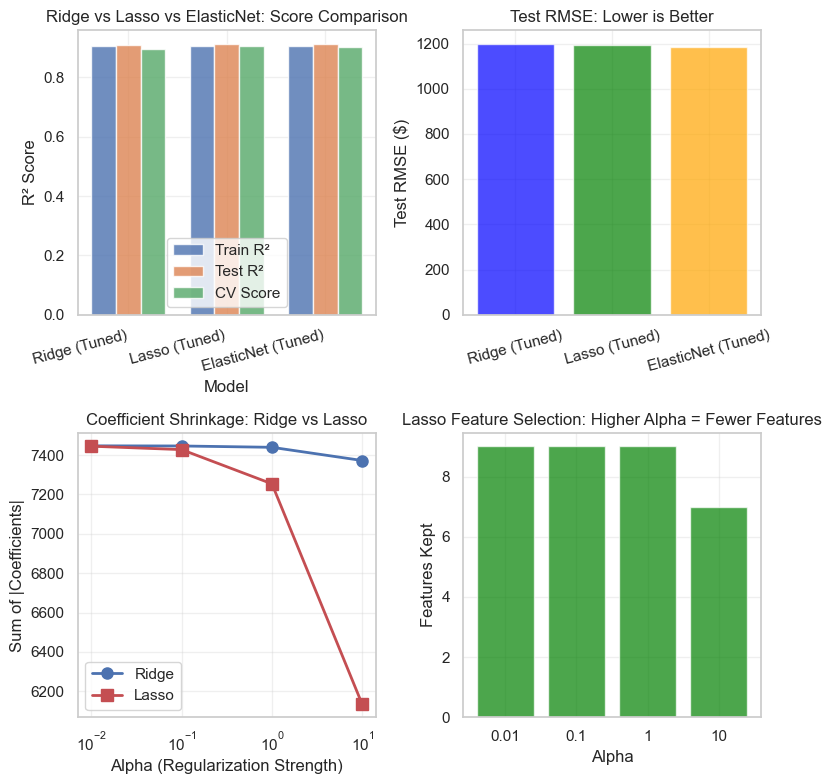


🎓 LEARNED

✅ RIDGE (L2):
   - Best alpha: 10
   - Effect: Shrinks coefficients but keeps ALL features
   - Use when: All features are somewhat useful

✅ LASSO (L1):
   - Best alpha: 10
   - Effect: Removes 2 features (coefficient = 0)
   - Use when: Want automatic feature selection

✅ ELASTIC NET:
   - Best alpha: 0.01
   - Best l1_ratio: 0.5
   - Effect: Balance between Ridge and Lasso
   - Use when: Many correlated features

🔑 KEY TAKEAWAY:
   RandomizedSearchCV automatically finds the best hyperparameters.
   No more guessing! It tries combinations and picks the winner.

   For diamonds, the optimal alpha is typically SMALL because:
   - Carat, cut, color, clarity are ALL genuinely important
   - Too much regularization hurts performance



In [75]:
from sklearn.model_selection import RandomizedSearchCV
# ============================================================
# PART 1: TUNE RIDGE (alpha only)
# ============================================================
print("\n" + "=" * 70)
print("PART 1: RIDGE REGRESSION - TUNING ALPHA")
print("=" * 70)
print("Parameter: alpha = [0.01, 0.1, 1, 10]")
print("Goal: Find alpha that gives best CV score")

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Define search space
ridge_params = {
    'regressor__alpha': [0.01, 0.1, 1, 10]
}

# RandomizedSearchCV (tries all 4 values since small)
ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    ridge_params,
    n_iter=4,           # Try all 4 values
    cv=5,               # 5-fold cross-validation
    scoring='r2',       # Optimize for R²
    random_state=42,
    n_jobs=-1,
    verbose=1
)

ridge_search.fit(X_train, y_train)

print(f"\n✅ Best Ridge alpha: {ridge_search.best_params_['regressor__alpha']}")
print(f"✅ Best CV R²: {ridge_search.best_score_:.4f}")

# Get best model
best_ridge = ridge_search.best_estimator_

# Evaluate on test set
ridge_train_r2 = r2_score(y_train, best_ridge.predict(X_train))
ridge_test_r2 = r2_score(y_test, best_ridge.predict(X_test))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, best_ridge.predict(X_test)))

print(f"Train R²: {ridge_train_r2:.4f}")
print(f"Test R²:  {ridge_test_r2:.4f}")
print(f"Test RMSE: ${ridge_test_rmse:.2f}")

# Show coefficients for each alpha
print(f"\n📊 Coefficients for each alpha:")
for alpha in [0.01, 0.1, 1, 10]:
    temp_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=alpha))
    ])
    temp_pipe.fit(X_train, y_train)
    coefs = temp_pipe.named_steps['regressor'].coef_
    print(f"alpha={alpha:5.2f}: Sum of |coefficients| = {np.sum(np.abs(coefs)):.2f}")

# ============================================================
# PART 2: TUNE LASSO (alpha only) ⭐ FEATURE SELECTION
# ============================================================
print("\n" + "=" * 70)
print("PART 2: LASSO REGRESSION - TUNING ALPHA")
print("=" * 70)
print("Parameter: alpha = [0.01, 0.1, 1, 10]")
print("Goal: Find alpha that removes useless features without hurting score")

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=10000))
])

lasso_params = {
    'regressor__alpha': [0.01, 0.1, 1, 10]
}

lasso_search = RandomizedSearchCV(
    lasso_pipeline,
    lasso_params,
    n_iter=4,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lasso_search.fit(X_train, y_train)

print(f"\n✅ Best Lasso alpha: {lasso_search.best_params_['regressor__alpha']}")
print(f"✅ Best CV R²: {lasso_search.best_score_:.4f}")

best_lasso = lasso_search.best_estimator_

lasso_train_r2 = r2_score(y_train, best_lasso.predict(X_train))
lasso_test_r2 = r2_score(y_test, best_lasso.predict(X_test))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, best_lasso.predict(X_test)))

print(f"Train R²: {lasso_train_r2:.4f}")
print(f"Test R²:  {lasso_test_r2:.4f}")
print(f"Test RMSE: ${lasso_test_rmse:.2f}")

# Show feature selection for each alpha
feature_names = (numerical_features + 
                list(preprocessor.named_transformers_['cat']
                    .named_steps['ordinal']
                    .get_feature_names_out(categorical_features)))

print(f"\n📊 Feature Selection for each alpha:")
for alpha in [0.01, 0.1, 1, 10]:
    temp_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=alpha, max_iter=10000))
    ])
    temp_pipe.fit(X_train, y_train)
    coefs = temp_pipe.named_steps['regressor'].coef_
    non_zero = np.sum(coefs != 0)
    zero = np.sum(coefs == 0)
    print(f"alpha={alpha:5.2f}: Keeps {non_zero} features, Removes {zero} features")

# Show WHICH features were removed by best Lasso
best_lasso_coefs = best_lasso.named_steps['regressor'].coef_
print(f"\n🎯 Best Lasso (alpha={lasso_search.best_params_['regressor__alpha']}) Feature Selection:")
for name, coef in zip(feature_names, best_lasso_coefs):
    status = "✅ KEPT" if coef != 0 else "❌ REMOVED"
    print(f"   {name:15s}: {coef:10.2f} {status}")

# ============================================================
# PART 3: TUNE ELASTIC NET (alpha + l1_ratio)
# ============================================================
print("\n" + "=" * 70)
print("PART 3: ELASTIC NET - TUNING ALPHA + L1_RATIO")
print("=" * 70)
print("Parameters: alpha = [0.01, 0.1, 1, 10], l1_ratio = [0.2, 0.5, 0.8]")
print("l1_ratio = 0 → pure Ridge, l1_ratio = 1 → pure Lasso")

elastic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(max_iter=10000))
])

elastic_params = {
    'regressor__alpha': [0.01, 0.1, 1, 10],
    'regressor__l1_ratio': [0.2, 0.5, 0.8]
}

elastic_search = RandomizedSearchCV(
    elastic_pipeline,
    elastic_params,
    n_iter=8,           # Try 8 random combinations
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

elastic_search.fit(X_train, y_train)

print(f"\n✅ Best ElasticNet alpha: {elastic_search.best_params_['regressor__alpha']}")
print(f"✅ Best ElasticNet l1_ratio: {elastic_search.best_params_['regressor__l1_ratio']}")
print(f"✅ Best CV R²: {elastic_search.best_score_:.4f}")

best_elastic = elastic_search.best_estimator_

elastic_train_r2 = r2_score(y_train, best_elastic.predict(X_train))
elastic_test_r2 = r2_score(y_test, best_elastic.predict(X_test))
elastic_test_rmse = np.sqrt(mean_squared_error(y_test, best_elastic.predict(X_test)))

print(f"Train R²: {elastic_train_r2:.4f}")
print(f"Test R²:  {elastic_test_r2:.4f}")
print(f"Test RMSE: ${elastic_test_rmse:.2f}")

# ============================================================
# PART 4: COMPARISON TABLE
# ============================================================
print("\n" + "=" * 70)
print("PART 4: FINAL COMPARISON TABLE")
print("=" * 70)

comparison = pd.DataFrame({
    'Model': ['Ridge (Tuned)', 'Lasso (Tuned)', 'ElasticNet (Tuned)'],
    'Best Alpha': [
        ridge_search.best_params_['regressor__alpha'],
        lasso_search.best_params_['regressor__alpha'],
        elastic_search.best_params_['regressor__alpha']
    ],
    'Best L1 Ratio': ['N/A (L2 only)', '1.0 (L1 only)', elastic_search.best_params_['regressor__l1_ratio']],
    'Train R²': [ridge_train_r2, lasso_train_r2, elastic_train_r2],
    'Test R²': [ridge_test_r2, lasso_test_r2, elastic_test_r2],
    'Test RMSE': [ridge_test_rmse, lasso_test_rmse, elastic_test_rmse],
    'CV Score': [ridge_search.best_score_, lasso_search.best_score_, elastic_search.best_score_]
})

print(comparison.round(4).to_string(index=False))

# ============================================================
# PART 5: VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Plot 1: R² Comparison
x_pos = np.arange(len(comparison))
width = 0.25

axes[0, 0].bar(x_pos - width, comparison['Train R²'], width, label='Train R²', alpha=0.8)
axes[0, 0].bar(x_pos, comparison['Test R²'], width, label='Test R²', alpha=0.8)
axes[0, 0].bar(x_pos + width, comparison['CV Score'], width, label='CV Score', alpha=0.8)
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Ridge vs Lasso vs ElasticNet: Score Comparison')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(comparison['Model'], rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: RMSE Comparison
axes[0, 1].bar(comparison['Model'], comparison['Test RMSE'], 
              color=['blue', 'green', 'orange'], alpha=0.7)
axes[0, 1].set_ylabel('Test RMSE ($)')
axes[0, 1].set_title('Test RMSE: Lower is Better')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Coefficient shrinkage visualization
alphas = [0.01, 0.1, 1, 10]
ridge_coef_sums = []
lasso_coef_sums = []

for alpha in alphas:
    r = Pipeline([('preprocessor', preprocessor), ('regressor', Ridge(alpha=alpha))])
    r.fit(X_train, y_train)
    ridge_coef_sums.append(np.sum(np.abs(r.named_steps['regressor'].coef_)))
    
    l = Pipeline([('preprocessor', preprocessor), ('regressor', Lasso(alpha=alpha, max_iter=10000))])
    l.fit(X_train, y_train)
    lasso_coef_sums.append(np.sum(np.abs(l.named_steps['regressor'].coef_)))

axes[1, 0].plot(alphas, ridge_coef_sums, 'bo-', label='Ridge', linewidth=2, markersize=8)
axes[1, 0].plot(alphas, lasso_coef_sums, 'rs-', label='Lasso', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Alpha (Regularization Strength)')
axes[1, 0].set_ylabel('Sum of |Coefficients|')
axes[1, 0].set_title('Coefficient Shrinkage: Ridge vs Lasso')
axes[1, 0].set_xscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Feature selection by Lasso
lasso_features_kept = []
for alpha in alphas:
    l = Pipeline([('preprocessor', preprocessor), ('regressor', Lasso(alpha=alpha, max_iter=10000))])
    l.fit(X_train, y_train)
    lasso_features_kept.append(np.sum(l.named_steps['regressor'].coef_ != 0))

axes[1, 1].bar(range(len(alphas)), lasso_features_kept, color='green', alpha=0.7)
axes[1, 1].set_xlabel('Alpha')
axes[1, 1].set_ylabel('Features Kept')
axes[1, 1].set_title('Lasso Feature Selection: Higher Alpha = Fewer Features')
axes[1, 1].set_xticks(range(len(alphas)))
axes[1, 1].set_xticklabels(alphas)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/rajuram/Desktop/Diamond-Price-Prediction_2/images/hyperparameter_tuning_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STUDENT SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("🎓 LEARNED")
print("=" * 70)

print(f"""
✅ RIDGE (L2):
   - Best alpha: {ridge_search.best_params_['regressor__alpha']}
   - Effect: Shrinks coefficients but keeps ALL features
   - Use when: All features are somewhat useful

✅ LASSO (L1):
   - Best alpha: {lasso_search.best_params_['regressor__alpha']}
   - Effect: Removes {np.sum(best_lasso_coefs == 0)} features (coefficient = 0)
   - Use when: Want automatic feature selection

✅ ELASTIC NET:
   - Best alpha: {elastic_search.best_params_['regressor__alpha']}
   - Best l1_ratio: {elastic_search.best_params_['regressor__l1_ratio']}
   - Effect: Balance between Ridge and Lasso
   - Use when: Many correlated features

🔑 KEY TAKEAWAY:
   RandomizedSearchCV automatically finds the best hyperparameters.
   No more guessing! It tries combinations and picks the winner.
   
   For diamonds, the optimal alpha is typically SMALL because:
   - Carat, cut, color, clarity are ALL genuinely important
   - Too much regularization hurts performance
""")